# Dynamic Analytical Dashboard with Python
### Sales, Customer Satisfaction and Order Cancellation Analysis for ShopEase

**Course:** Foundations of Big Data Analytics with Python (FBDA)

---

## 1. Project Information

| | |
|---|---|
| **Project Title** | Dynamic Analytical Dashboard with Python: Sales, Satisfaction and Cancellation Analytics for ShopEase |
| **Student Name** | Arkaprava Dey, Dhruv Singh, Tushar Raj |
| **Enrollment Number** | 075011, 075023, 075048 |
| **Group Number** | 011_023_048 |
| **Live Data Link** | *[raw GitHub link of shopease_raw_orders.csv]* |
| **Live Dashboard Link** | *[Streamlit dashboard link]* |

## 2. Description of Data

| Item | Details |
|---|---|
| **Data Name** | ShopEase Raw Orders (`shopease_raw_orders.csv`) |
| **Data Source (weblink)** | Project dataset shared with the brief; hosted for this notebook at the live data link above |
| **Data Size** | about 1.19 MB (1,191,930 bytes) |
| **Data Type** | Cross-sectional. Each row is one order. `OrderDate` also lets us build a daily/monthly time series. |
| **Dataset Span** | Static. Orders placed between January and June 2026; the file is not updated. |
| **Data Dimension** | 16 variables and 10,020 observations in the raw file (10,000 after cleaning). We analyse a random sample of 2,500 records. |
| **Data Format** | Text (String): CustomerID, OrderDate, Gender, City, Category, Product, Discount, PaymentMethod, OrderStatus, DeliveryDate. Number (Integer): OrderID, CustomerAge, Quantity, UnitPrice. Number (Decimal): Rating, TotalAmount. |

The variable types, definitions and missing values are shown in the cells below.

In [1]:
# libraries listed in the project guidelines
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

# group id = last 3 digits of our roll numbers (075011, 075023, 075048)
GROUP_ID = "011_023_048"
# the brief turns 001_010_100 into 110100, i.e. leading zeros are dropped before joining
SEED = int("".join(str(int(part)) for part in GROUP_ID.split("_")))
random.seed(SEED)
np.random.seed(SEED)
print("Group:", GROUP_ID, "| seed used for random.seed and random_state:", SEED)

Group: 011_023_048 | seed used for random.seed and random_state: 112348


In [2]:
# the data is read straight from the live data link
DATA_URL = "https://raw.githubusercontent.com/<your-username>/<your-repo>/main/shopease_raw_orders.csv"
raw = pd.read_csv(DATA_URL)

print("Rows, columns:", raw.shape)
raw.head(10)

Rows, columns: (10020, 16)


,OrderID,CustomerID,OrderDate,CustomerAge,Gender,City,Category,Product,Quantity,UnitPrice,Discount,PaymentMethod,OrderStatus,DeliveryDate,Rating,TotalAmount
0,18129,C0507,2026-02-01 23:39:00,68.0000,Female,Alexandria,Electronics,Laptop,4,18000,0.0,Wallet,Delivered,2026-02-04 23:39:00,5.0000,"72,000.0000"
1,11666,C0207,2026-03-03 10:37:00,21.0000,Female,Cairo,Sports,Yoga Mat,2,600,0.1,Wallet,Delivered,2026-03-07 10:37:00,1.0000,"1,080.0000"
2,12859,C1112,2026-05-23 17:57:00,23.0000,Male,Aswan,Fashion,Shoes,-1,1500,10%,Bank Transfer,Delivered,2026-05-27 17:57:00,4.0000,"1,350.0000"
3,19787,C1322,2026-01-29 07:51:00,23.0000,Male,Tanta,Beauty,Hair Dryer,4,1300,0.1,Wallet,Delivered,2026-01-30 07:51:00,4.0000,"4,680.0000"
4,16473,C0314,2026-06-23 20:17:00,62.0000,Female,Tanta,Electronics,Laptop,1,18000,0.1,Mastercard,Delivered,2026-06-27 20:17:00,5.0000,"16,200.0000"
5,18080,C0405,2026-05-03 07:49:00,53.0000,Female,Giza,Fashion,Jacket,4,1200,0.1,Wallet,Delivered,2026-05-05 07:49:00,5.0000,"4,320.0000"
6,16083,C1290,2026-03-14 01:55:00,38.0000,Female,Tanta,Sports,Tennis Racket,2,1600,0.1,Visa,Delivered,2026-03-16 01:55:00,3.0000,"2,880.0000"
7,17384,C1810,2026-06-26 17:19:00,56.0000,Male,Giza,Beauty,Makeup Kit,4,900,0.1,Visa,Delivered,2026-06-29 17:19:00,4.0000,"3,240.0000"
8,18401,C0683,24-02-2026,40.0000,Female,Cairo,Sports,Running Shoes,4,1800,0.0,Wallet,Delivered,2026-02-26 07:50:00,3.0000,"7,200.0000"
9,13145,C0967,2026-03-18 16:44:00,49.0000,Female,Mansoura,Home,Lamp,3,300,0.2,Cash,Pending,NaN,NaN,720.0000


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        10020 non-null  int64  
 1   CustomerID     10005 non-null  str    
 2   OrderDate      10020 non-null  str    
 3   CustomerAge    9900 non-null   float64
 4   Gender         10020 non-null  str    
 5   City           10020 non-null  str    
 6   Category       10020 non-null  str    
 7   Product        10000 non-null  str    
 8   Quantity       10020 non-null  int64  
 9   UnitPrice      10020 non-null  int64  
 10  Discount       9920 non-null   str    
 11  PaymentMethod  9970 non-null   str    
 12  OrderStatus    10020 non-null  str    
 13  DeliveryDate   7790 non-null   str    
 14  Rating         7728 non-null   float64
 15  TotalAmount    10020 non-null  float64
dtypes: float64(3), int64(3), str(10)
memory usage: 2.0 MB


**Data variable types and definitions**

The table below classifies every variable using the scheme in the guidelines: Categorical (Nominal / Ordinal) or Non-Categorical (Index / Non-Index).

In [4]:
variables = pd.DataFrame([
    ["OrderID",       "Unique number given to each order",                  "Non-Categorical - Index (Nominal)",    "Number (Integer)"],
    ["CustomerID",    "Customer code, e.g. C0507",                          "Non-Categorical - Index (Nominal)",    "Text (String)"],
    ["OrderDate",     "Date and time the order was placed",                 "Non-Categorical - Index (Date)",       "Text (String)"],
    ["CustomerAge",   "Age of the customer in years",                       "Non-Categorical - Non-Index (Ratio)",  "Number (Integer)"],
    ["Gender",        "Male / Female",                                      "Categorical - Nominal",                "Text (String)"],
    ["City",          "Customer's city (6 cities in Egypt)",                "Categorical - Nominal",                "Text (String)"],
    ["Category",      "Product category (5)",                               "Categorical - Nominal",                "Text (String)"],
    ["Product",       "Product name (25)",                                  "Categorical - Nominal",                "Text (String)"],
    ["Quantity",      "Units bought in the order (1-4)",                    "Non-Categorical - Non-Index (Ratio)",  "Number (Integer)"],
    ["UnitPrice",     "Price of one unit in EGP",                           "Non-Categorical - Non-Index (Ratio)",  "Number (Integer)"],
    ["Discount",      "Discount given: 0%, 5%, 10%, 15% or 20%",            "Categorical - Ordinal",                "Text (String)"],
    ["PaymentMethod", "Cash, Visa, Mastercard, Wallet or Bank Transfer",    "Categorical - Nominal",                "Text (String)"],
    ["OrderStatus",   "Delivered, Pending or Cancelled",                    "Categorical - Nominal",                "Text (String)"],
    ["DeliveryDate",  "Date and time the order reached the customer",       "Non-Categorical - Index (Date)",       "Text (String)"],
    ["Rating",        "Customer rating from 1 to 5",                        "Categorical - Ordinal",                "Number (Decimal)"],
    ["TotalAmount",   "Amount paid = Quantity x UnitPrice x (1 - Discount)", "Non-Categorical - Non-Index (Ratio)", "Number (Decimal)"],
], columns=["Variable", "Definition", "Variable Type", "Data Format"])
variables

,Variable,Definition,Variable Type,Data Format
0,OrderID,Unique number given to each order,Non-Categorical - Index (Nominal),Number (Integer)
1,CustomerID,"Customer code, e.g. C0507",Non-Categorical - Index (Nominal),Text (String)
2,OrderDate,Date and time the order was placed,Non-Categorical - Index (Date),Text (String)
3,CustomerAge,Age of the customer in years,Non-Categorical - Non-Index (Ratio),Number (Integer)
4,Gender,Male / Female,Categorical - Nominal,Text (String)
5,City,Customer's city (6 cities in Egypt),Categorical - Nominal,Text (String)
6,Category,Product category (5),Categorical - Nominal,Text (String)
7,Product,Product name (25),Categorical - Nominal,Text (String)
8,Quantity,Units bought in the order (1-4),Non-Categorical - Non-Index (Ratio),Number (Integer)
9,UnitPrice,Price of one unit in EGP,Non-Categorical - Non-Index (Ratio),Number (Integer)


**Missing data information**

In [5]:
missing = pd.DataFrame({"Missing": raw.isna().sum(), "Missing %": (raw.isna().mean() * 100).round(2)})
missing[missing["Missing"] > 0]

,Missing,Missing %
CustomerID,15,0.1500
CustomerAge,120,1.2000
Product,20,0.2000
Discount,100,1.0000
PaymentMethod,50,0.5000
DeliveryDate,2230,22.2600
Rating,2292,22.8700


Most blanks are in `DeliveryDate` and `Rating`. These belong almost entirely to pending and cancelled orders, which were never delivered or rated, so we leave them blank on purpose. The smaller gaps in age, discount, product, payment method and customer ID are handled in the cleaning step (4.1). Apart from blanks, the raw file also has duplicate rows, several spellings of the same city or gender, discounts written two ways, and some impossible values (negative quantities, zero prices, ages like 150).

## 3. Project Objectives | Problem Statements

1. Turn the messy raw order file into a clean, reliable dataset and record every change made.
2. Describe ShopEase's customers and orders: who buys, from which city, which categories, how they pay and how much they spend.
3. Find out what drives the value of an order (quantity, price, discount, category, city, customer profile).
4. Check whether customer ratings depend on delivery time, discount, category, payment method or gender.
5. Check whether order cancellations are linked to any product or customer characteristic.
6. Test whether spending, ratings and cancellations differ significantly between groups.
7. Look at how orders and revenue move from month to month.
8. Build a Streamlit dashboard so a manager can filter the data and repeat the analysis on any segment.

## 4. Analysis of Data

### 4.1 Data Preparation

Before any statistics, the raw file needs cleaning. The function below does it step by step and writes a short note for each fix. The dashboard uses the same function, so both give the same numbers.

In [6]:
VALID_DISC = np.array([0.0, 0.05, 0.10, 0.15, 0.20])   # the only discount levels ShopEase uses


def parse_date(x):
    # OrderDate comes in about six different formats, so we try each one in turn
    if pd.isna(x):
        return pd.NaT
    s = str(x).strip()
    if s.lower() in ("not available", "na", "n/a", ""):
        return pd.NaT
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%b %d %Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT


def clean_data(raw):
    df = raw.copy()
    notes = []            # we keep a short note of every fix so it can go into the report
    n_start = len(df)

    # text columns: extra spaces and mixed case ("male", " Male", "M", "FEMALE" ...)
    for c in ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "CustomerID"]:
        df[c] = df[c].str.strip()
    df["Gender"] = df["Gender"].str.lower().map({"male": "Male", "m": "Male", "female": "Female", "f": "Female"})
    df["City"] = df["City"].str.title()
    df["Category"] = df["Category"].str.title()
    df["Product"] = df["Product"].str.title()
    df["PaymentMethod"] = df["PaymentMethod"].str.title()
    df["OrderStatus"] = df["OrderStatus"].str.title().replace({"Canceled": "Cancelled"})
    notes.append("Trimmed spaces and fixed spelling/case in Gender, City, Category, Product, PaymentMethod and OrderStatus")

    # duplicates - first exact copies, then repeated OrderIDs (we keep the row with fewer blanks)
    exact_dups = df.duplicated().sum()
    df = df.drop_duplicates()
    df["_blanks"] = df.isna().sum(axis=1)
    df = df.sort_values(["OrderID", "_blanks"])
    id_dups = df["OrderID"].duplicated().sum()
    df = df.drop_duplicates("OrderID", keep="first").drop(columns="_blanks")
    notes.append(f"Removed {exact_dups} exact duplicate rows and {id_dups} more rows with a repeated OrderID")

    # dates
    df["OrderDate"] = df["OrderDate"].apply(parse_date)
    df["DeliveryDate"] = pd.to_datetime(df["DeliveryDate"], errors="coerce")
    notes.append(f"Converted OrderDate from its mixed formats; {df['OrderDate'].isna().sum()} dates marked 'not available' were left blank")

    # discount is stored both as 0.1 and as "10%"
    disc = pd.to_numeric(df["Discount"].str.strip().str.rstrip("%"), errors="coerce").astype(float)
    df["Discount"] = np.where(disc > 1, disc / 100, disc)

    # every product has one list price, so 0, -500 and 75k+ prices are entry errors
    list_price = df[df["UnitPrice"] > 0].groupby("Product")["UnitPrice"].agg(lambda s: s.mode().iloc[0])
    wrong_price = (df["UnitPrice"] != df["Product"].map(list_price)) & df["Product"].notna()
    df.loc[wrong_price, "UnitPrice"] = df.loc[wrong_price, "Product"].map(list_price)
    notes.append(f"Replaced {int(wrong_price.sum())} impossible UnitPrice values with the product's normal price")

    # a missing product name can be recovered when category + price point to only one product
    lookup = df.dropna(subset=["Product"]).groupby(["Category", "UnitPrice"])["Product"].agg(
        lambda s: s.mode().iloc[0] if s.nunique() == 1 else np.nan)
    no_product = df["Product"].isna()
    df.loc[no_product, "Product"] = [lookup.get((c, p), np.nan)
                                     for c, p in zip(df.loc[no_product, "Category"], df.loc[no_product, "UnitPrice"])]
    df["Product"] = df["Product"].fillna("Unknown")
    notes.append(f"Filled {int(no_product.sum() - (df['Product'] == 'Unknown').sum())} missing Product names using Category and UnitPrice")

    # negative quantity looks like a sign error; zero quantity is worked back from TotalAmount
    neg_qty = (df["Quantity"] < 0).sum()
    df["Quantity"] = df["Quantity"].abs()
    zero_qty = df["Quantity"] == 0
    d = df["Discount"].fillna(0)
    df.loc[zero_qty, "Quantity"] = (df.loc[zero_qty, "TotalAmount"] /
                                    (df.loc[zero_qty, "UnitPrice"] * (1 - d[zero_qty]))).round().clip(1, 4)
    df["Quantity"] = df["Quantity"].astype(int)
    notes.append(f"Fixed {neg_qty} negative quantities and {int(zero_qty.sum())} zero quantities")

    # missing discount: back it out of TotalAmount and round to the nearest real discount level
    no_disc = df["Discount"].isna()
    implied = 1 - df.loc[no_disc, "TotalAmount"] / (df.loc[no_disc, "Quantity"] * df.loc[no_disc, "UnitPrice"])
    df.loc[no_disc, "Discount"] = [VALID_DISC[np.abs(VALID_DISC - v).argmin()] for v in implied]
    notes.append(f"Filled {int(no_disc.sum())} missing discounts from TotalAmount / (Quantity x UnitPrice)")

    # recompute TotalAmount so every row adds up
    new_total = (df["Quantity"] * df["UnitPrice"] * (1 - df["Discount"])).round(2)
    changed = (~np.isclose(new_total, df["TotalAmount"])).sum()
    df["TotalAmount"] = new_total
    notes.append(f"Recalculated TotalAmount = Quantity x UnitPrice x (1 - Discount); {changed} rows changed")

    # ages like -3, 5 or 150 are not real customers -> blank, then median
    bad_age = (df["CustomerAge"] < 18) | (df["CustomerAge"] > 80)
    n_bad_age = bad_age.sum()
    df.loc[bad_age, "CustomerAge"] = np.nan
    n_missing_age = df["CustomerAge"].isna().sum()
    df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median()).astype(int)
    notes.append(f"Blanked {n_bad_age} impossible ages and filled {n_missing_age} missing ages with the median")

    # rating must be 1-5; blanks are normal for orders that were never delivered
    bad_rating = (~df["Rating"].between(1, 5) & df["Rating"].notna()).sum()
    df.loc[~df["Rating"].between(1, 5), "Rating"] = np.nan
    notes.append(f"Removed {bad_rating} ratings outside 1-5 (blank ratings for undelivered orders were kept as blank)")

    df["CustomerID"] = df["CustomerID"].fillna("Unknown")
    top_payment = df["PaymentMethod"].mode().iloc[0]
    df["PaymentMethod"] = df["PaymentMethod"].fillna(top_payment)
    notes.append(f"Missing CustomerID set to 'Unknown'; missing PaymentMethod filled with the most common method ({top_payment})")

    # a few helper columns we use later
    df["DeliveryDays"] = (df["DeliveryDate"] - df["OrderDate"]).dt.days
    df.loc[df["DeliveryDays"] < 0, "DeliveryDays"] = np.nan
    df["OrderMonth"] = df["OrderDate"].dt.strftime("%Y-%m")
    df["DiscountPct"] = (df["Discount"] * 100).round().astype(int)
    df["AgeGroup"] = pd.cut(df["CustomerAge"], [17, 25, 35, 45, 55, 65, 80],
                            labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66-80"]).astype(object)
    df["IsCancelled"] = (df["OrderStatus"] == "Cancelled").astype(int)
    df["HighRating"] = np.where(df["Rating"].isna(), np.nan, (df["Rating"] >= 4).astype(float))
    notes.append("Added DeliveryDays, OrderMonth, DiscountPct, AgeGroup, IsCancelled and HighRating")

    df = df.reset_index(drop=True)
    notes.append(f"Rows: {n_start} in the raw file -> {len(df)} after cleaning")
    return df, notes

In [7]:
clean, notes = clean_data(raw)
for i, n in enumerate(notes, 1):
    print(f"{i}. {n}")

print("\nStill missing after cleaning (expected - orders never delivered or rated):")
print(clean.isna().sum()[clean.isna().sum() > 0])

1. Trimmed spaces and fixed spelling/case in Gender, City, Category, Product, PaymentMethod and OrderStatus
2. Removed 10 exact duplicate rows and 10 more rows with a repeated OrderID
3. Converted OrderDate from its mixed formats; 25 dates marked 'not available' were left blank
4. Replaced 40 impossible UnitPrice values with the product's normal price
5. Filled 20 missing Product names using Category and UnitPrice
6. Fixed 60 negative quantities and 20 zero quantities
7. Filled 99 missing discounts from TotalAmount / (Quantity x UnitPrice)
8. Recalculated TotalAmount = Quantity x UnitPrice x (1 - Discount); 140 rows changed
9. Blanked 25 impossible ages and filled 145 missing ages with the median
10. Removed 15 ratings outside 1-5 (blank ratings for undelivered orders were kept as blank)
11. Missing CustomerID set to 'Unknown'; missing PaymentMethod filled with the most common method (Cash)
12. Added DeliveryDays, OrderMonth, DiscountPct, AgeGroup, IsCancelled and HighRating
13. Rows: 

**Random sample of 2,500 records.** We draw the sample with our group seed so the same rows come out every time the notebook is run.

In [8]:
random.seed(SEED)
np.random.seed(SEED)
df = clean.sample(n=2500, random_state=SEED).reset_index(drop=True)

print("Sample size:", df.shape)
print("First five OrderIDs (quick check that the sample is reproducible):", df["OrderID"].head().tolist())

# ratings only exist for orders that were delivered, so we keep a separate frame for those
rated = df.dropna(subset=["Rating"]).copy()
delivered = df[df["OrderStatus"] == "Delivered"].copy()
print("Orders in sample:", len(df), "| delivered:", len(delivered), "| rated:", len(rated))

num_cols = ["CustomerAge", "Quantity", "UnitPrice", "Discount", "TotalAmount", "Rating", "DeliveryDays"]
cat_cols = ["Gender", "City", "Category", "Product", "PaymentMethod", "OrderStatus", "AgeGroup", "DiscountPct"]

Sample size: (2500, 22)
First five OrderIDs (quick check that the sample is reproducible): [11068, 18457, 19873, 10660, 16438]
Orders in sample: 2500 | delivered: 1974 | rated: 1947


### 4.2 Descriptive Statistics

#### 4.2.1 Non-categorical data
Count, minimum, maximum, percentiles, measures of central tendency (mean, median, mode) and measures of dispersion (range, standard deviation, skewness, kurtosis).

In [9]:
summary = {}
for col in num_cols:
    x = df[col].dropna()
    summary[col] = {
        "Count": x.count(), "Min": x.min(),
        "P5": x.quantile(0.05), "P25": x.quantile(0.25), "Median (P50)": x.median(),
        "P75": x.quantile(0.75), "P95": x.quantile(0.95), "Max": x.max(),
        "Mean": x.mean(), "Mode": x.mode().iloc[0],
        "Range": x.max() - x.min(), "Std Dev": x.std(),
        "Skewness": stats.skew(x), "Kurtosis": stats.kurtosis(x),   # excess kurtosis (normal = 0)
    }
num_summary = pd.DataFrame(summary).T
num_summary

,Count,Min,P5,P25,Median (P50),P75,P95,Max,Mean,Mode,Range,Std Dev,Skewness,Kurtosis
CustomerAge,"2,500.0000",18.0000,20.0000,31.0000,44.0000,57.0000,67.0000,70.0000,43.9052,44.0000,52.0000,15.0477,0.0023,-1.1870
Quantity,"2,500.0000",1.0000,1.0000,1.0000,2.0000,3.0000,4.0000,4.0000,1.9748,1.0000,3.0000,1.0531,0.7432,-0.7134
UnitPrice,"2,500.0000",250.0000,300.0000,650.0000,900.0000,"1,600.0000","2,500.0000","18,000.0000","1,831.1400",900.0000,"17,750.0000","3,516.4319",4.2572,16.6922
Discount,"2,500.0000",0.0000,0.0000,0.0000,0.0500,0.1000,0.1500,0.2000,0.0674,0.0000,0.2000,0.0616,0.4047,-0.9739
TotalAmount,"2,500.0000",200.0000,427.5000,855.0000,"1,530.0000","2,880.0000","7,920.0000","72,000.0000","3,366.3320",900.0000,"71,800.0000","7,637.2017",6.0146,40.4278
Rating,"1,947.0000",1.0000,2.0000,3.0000,4.0000,5.0000,5.0000,5.0000,3.9630,4.0000,4.0000,0.9895,-0.9224,0.4577
DeliveryDays,"1,949.0000",1.0000,1.0000,2.0000,3.0000,5.0000,6.0000,7.0000,3.5500,3.0000,6.0000,1.5243,0.3791,-0.4459


**Measures of correlation (Pearson and Spearman)** — on rated orders, so that Rating and DeliveryDays can be included.

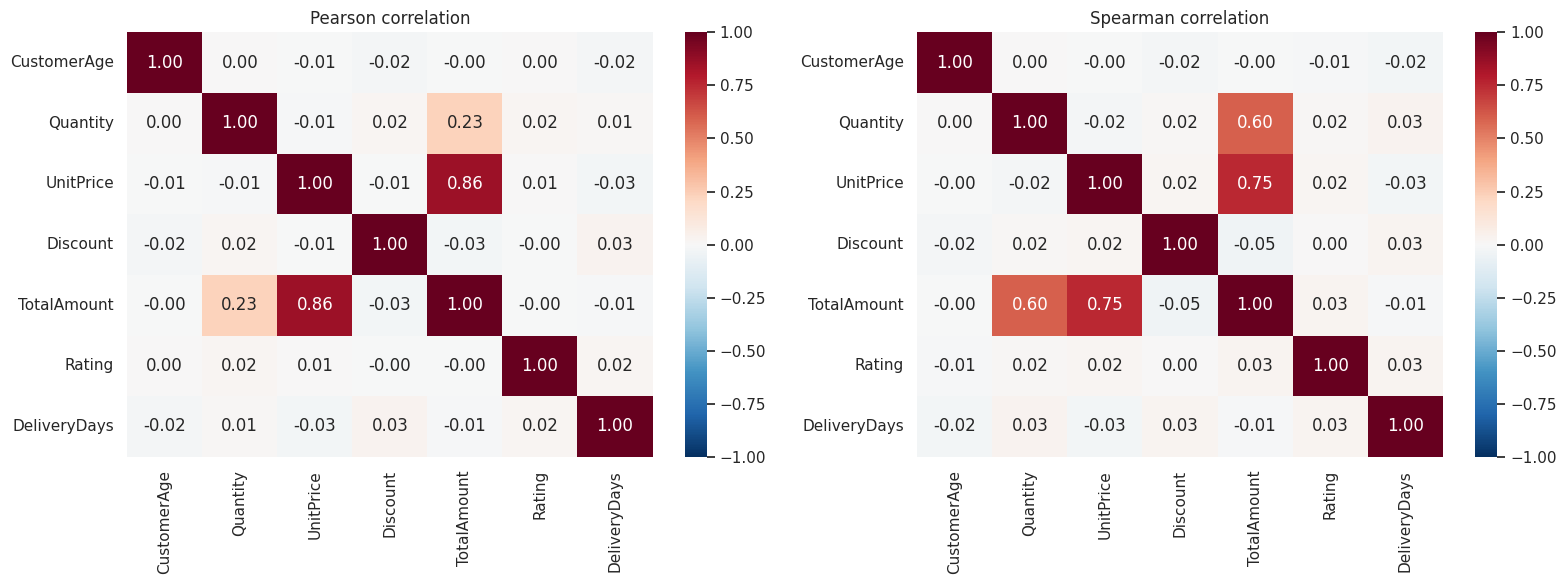

In [10]:
pearson = rated[num_cols].corr(method="pearson")
spearman = rated[num_cols].corr(method="spearman")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Pearson correlation")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("Spearman correlation")
plt.tight_layout()
plt.show()

**What the numbers say**

- Customers are between 18 and 70 years old, with a mean of 43.9 and a median of 44. Skewness is almost zero and kurtosis is -1.19, so ages are spread quite evenly rather than bunched around the middle.
- `TotalAmount` is very uneven. The mean order is EGP 3,366 but the median is only EGP 1,530; skewness is 6.0 and kurtosis 40.4. A small number of large orders (laptops) pull the mean up. `UnitPrice` shows the same pattern (skewness 4.3).
- The average order has about 2 units (mode 1). The average discount is 6.7%, and the most common discount is none at all.
- Ratings average 3.96 out of 5 (median and mode both 4). Delivery takes 3.55 days on average, between 1 and 7 days.
- In the correlation maps, `TotalAmount` moves with `UnitPrice` (Pearson 0.86) and `Quantity` (0.23; Spearman 0.60). Rating has almost no correlation with any numeric variable, including delivery days (0.02).

#### 4.2.2 Categorical data
Count, frequency, relative frequency (proportion) and the category with the highest / lowest frequency.

In [11]:
high_low = []
for col in cat_cols:
    counts = df[col].value_counts()
    table = pd.DataFrame({"Frequency": counts,
                          "Relative Frequency": (counts / counts.sum()).round(4),
                          "Percent": (counts / counts.sum() * 100).round(2)})
    print(f"\n{col}")
    display(table)
    high_low.append({"Variable": col, "Count": counts.sum(), "Levels": len(counts),
                     "Highest": counts.idxmax(), "Highest %": round(counts.max() / counts.sum() * 100, 2),
                     "Lowest": counts.idxmin(), "Lowest %": round(counts.min() / counts.sum() * 100, 2)})


Gender


,Frequency,Relative Frequency,Percent
Gender,,,
Male,1257,0.5028,50.2800
Female,1243,0.4972,49.7200



City


,Frequency,Relative Frequency,Percent
City,,,
Cairo,957,0.3828,38.2800
Giza,486,0.1944,19.4400
Alexandria,440,0.1760,17.6000
Mansoura,268,0.1072,10.7200
Tanta,209,0.0836,8.3600
Aswan,140,0.0560,5.6000



Category


...

,Frequency,Relative Frequency,Percent
OrderStatus,,,
Delivered,1974,0.7896,78.9600
Pending,285,0.1140,11.4000
Cancelled,241,0.0964,9.6400



AgeGroup


,Frequency,Relative Frequency,Percent
AgeGroup,,,
36-45,492,0.1968,19.6800
56-65,491,0.1964,19.6400
26-35,484,0.1936,19.3600
46-55,465,0.1860,18.6000
18-25,367,0.1468,14.6800
66-80,201,0.0804,8.0400



DiscountPct


,Frequency,Relative Frequency,Percent
DiscountPct,,,
0,880,0.3520,35.2000
10,641,0.2564,25.6400
5,482,0.1928,19.2800
15,380,0.1520,15.2000
20,117,0.0468,4.6800


In [12]:
# one table with the most and least frequent category of each variable
pd.DataFrame(high_low)

,Variable,Count,Levels,Highest,Highest %,Lowest,Lowest %
0,Gender,2500,2,Male,50.2800,Female,49.7200
1,City,2500,6,Cairo,38.2800,Aswan,5.6000
2,Category,2500,5,Electronics,21.6400,Beauty,17.8400
3,Product,2500,25,Smart Watch,4.8800,Face Cream,3.3600
4,PaymentMethod,2500,5,Wallet,20.3600,Visa,19.5200
5,OrderStatus,2500,3,Delivered,78.9600,Cancelled,9.6400
6,AgeGroup,2500,6,36-45,19.6800,66-80,8.0400
7,DiscountPct,2500,5,0,35.2000,20,4.6800


In [13]:
# rating is ordinal, so a frequency table is the right summary
rating_counts = rated["Rating"].value_counts().sort_index()
print(pd.DataFrame({"Frequency": rating_counts, "Relative Frequency": (rating_counts / rating_counts.sum()).round(4)}))
print("\nMedian rating:", rated["Rating"].median(), "| Mode:", rated["Rating"].mode().iloc[0])

        Frequency  Relative Frequency
Rating                               
1.0000         44              0.0226
2.0000        137              0.0704
3.0000        315              0.1618
4.0000        802              0.4119
5.0000        649              0.3333

Median rating: 4.0 | Mode: 4.0


**What the numbers say**

- Men and women order almost equally (50.3% vs 49.7%).
- Cairo is by far the biggest market with 38.3% of orders; Aswan is the smallest with 5.6%.
- Electronics is the most ordered category (21.6%) and Beauty the least (17.8%). Among products, Smart Watch is ordered most (4.9%) and Face Cream least (3.4%).
- Payment methods are used almost equally, from Wallet (20.4%) down to Visa (19.5%).
- 79.0% of orders were delivered, 11.4% are pending and 9.6% were cancelled.
- The 36-45 age group is the largest (19.7%) and 66-80 the smallest (8.0%).
- 35.2% of orders had no discount; only 4.7% received the full 20%.
- 41.2% of ratings are 4 and 33.3% are 5, so three out of four customers are happy. About 9% gave 1 or 2 stars.

### 4.3 Visualization

#### 4.3.1 Non-categorical data: scatter plot, line plot, box-whisker plot, violin plot, heat map, pair plot

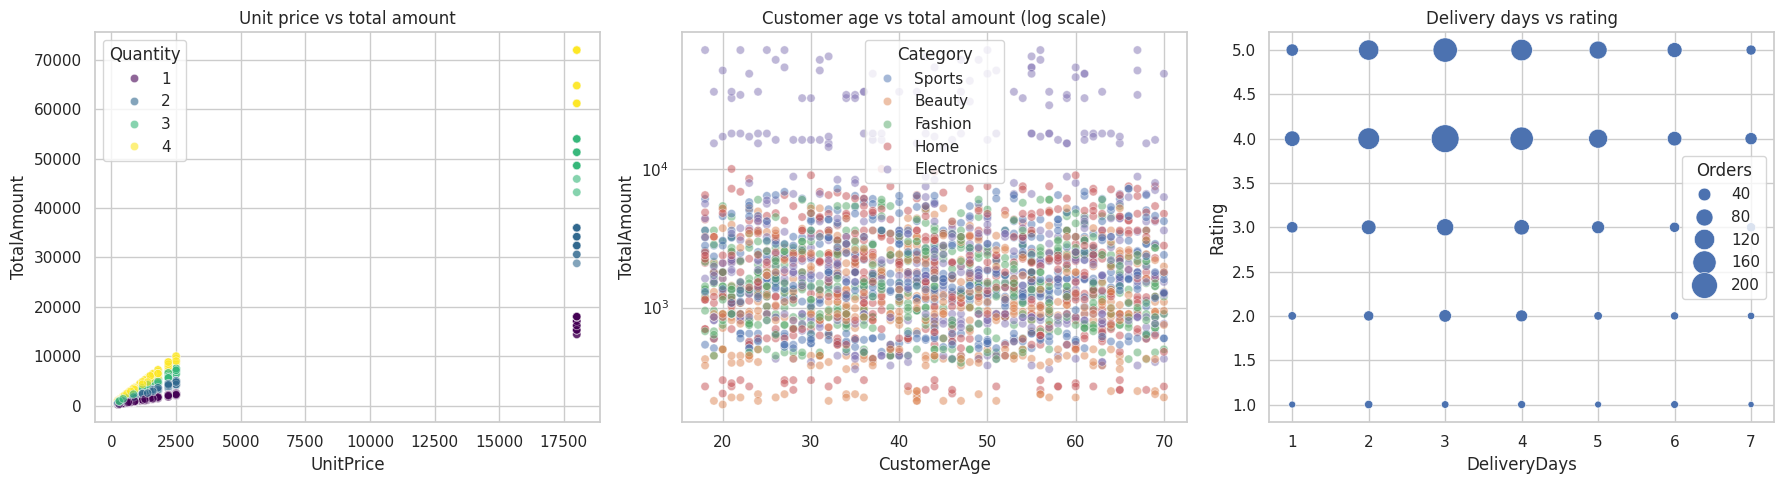

In [14]:
# scatter plots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x="UnitPrice", y="TotalAmount", hue="Quantity", palette="viridis", alpha=0.6, ax=ax[0])
ax[0].set_title("Unit price vs total amount")

sns.scatterplot(data=df, x="CustomerAge", y="TotalAmount", hue="Category", alpha=0.5, ax=ax[1])
ax[1].set_yscale("log")
ax[1].set_title("Customer age vs total amount (log scale)")

# rating and delivery days only take a few values, so we size each point by how many orders sit there
bubbles = rated.groupby(["DeliveryDays", "Rating"]).size().reset_index(name="Orders")
sns.scatterplot(data=bubbles, x="DeliveryDays", y="Rating", size="Orders", sizes=(20, 400), ax=ax[2])
ax[2].set_title("Delivery days vs rating")
plt.tight_layout()
plt.show()

,OrderMonth,Orders,Revenue,AvgOrderValue,CancelRate,AvgRating
0,2026-01,422,"1,563,232.5000","3,704.3424",0.0900,3.9323
1,2026-02,421,"1,333,435.0000","3,167.3040",0.0903,3.9970
2,2026-03,447,"1,471,560.0000","3,292.0805",0.1029,3.9705
3,2026-04,407,"1,293,645.0000","3,178.4889",0.1179,3.9871
4,2026-05,412,"1,331,970.0000","3,232.9369",0.0874,3.9116
5,2026-06,385,"1,398,532.5000","3,632.5519",0.0909,3.9771


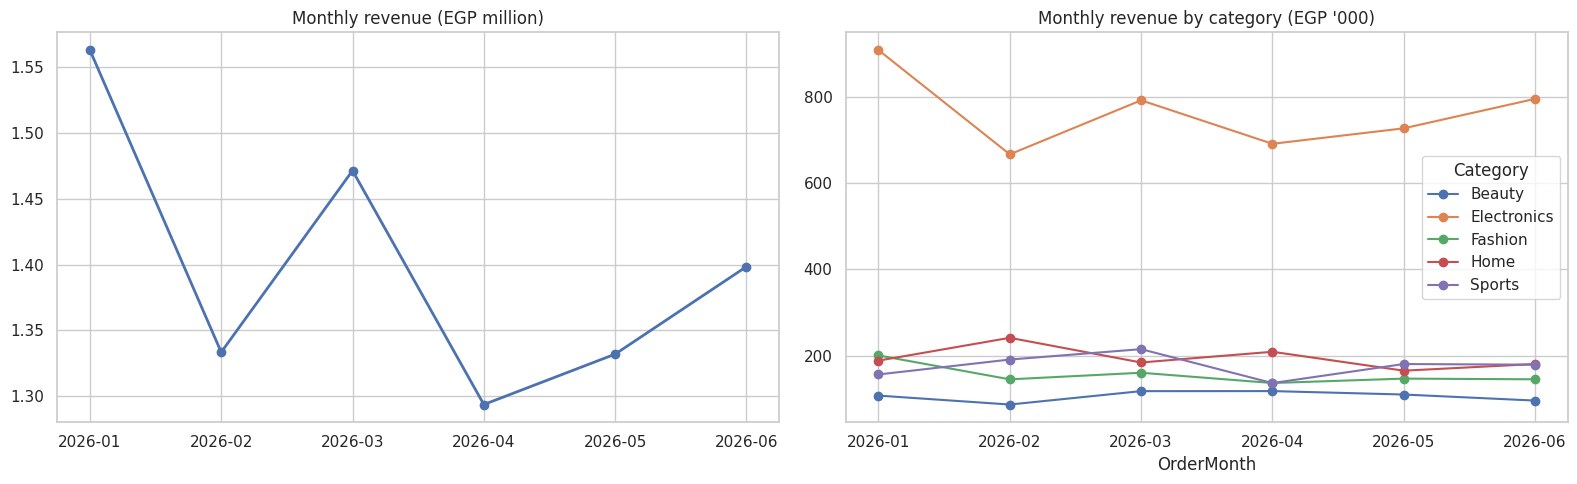

In [15]:
# line plots - month by month
monthly = (df.dropna(subset=["OrderMonth"])
             .groupby("OrderMonth")
             .agg(Orders=("OrderID", "count"), Revenue=("TotalAmount", "sum"),
                  AvgOrderValue=("TotalAmount", "mean"), CancelRate=("IsCancelled", "mean"),
                  AvgRating=("Rating", "mean"))
             .reset_index())
display(monthly)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(monthly["OrderMonth"], monthly["Revenue"] / 1e6, marker="o", linewidth=2)
ax[0].set_title("Monthly revenue (EGP million)")

by_cat = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category",
                                                      values="TotalAmount", aggfunc="sum")
(by_cat / 1e3).plot(marker="o", ax=ax[1])
ax[1].set_title("Monthly revenue by category (EGP '000)")
plt.tight_layout()
plt.show()

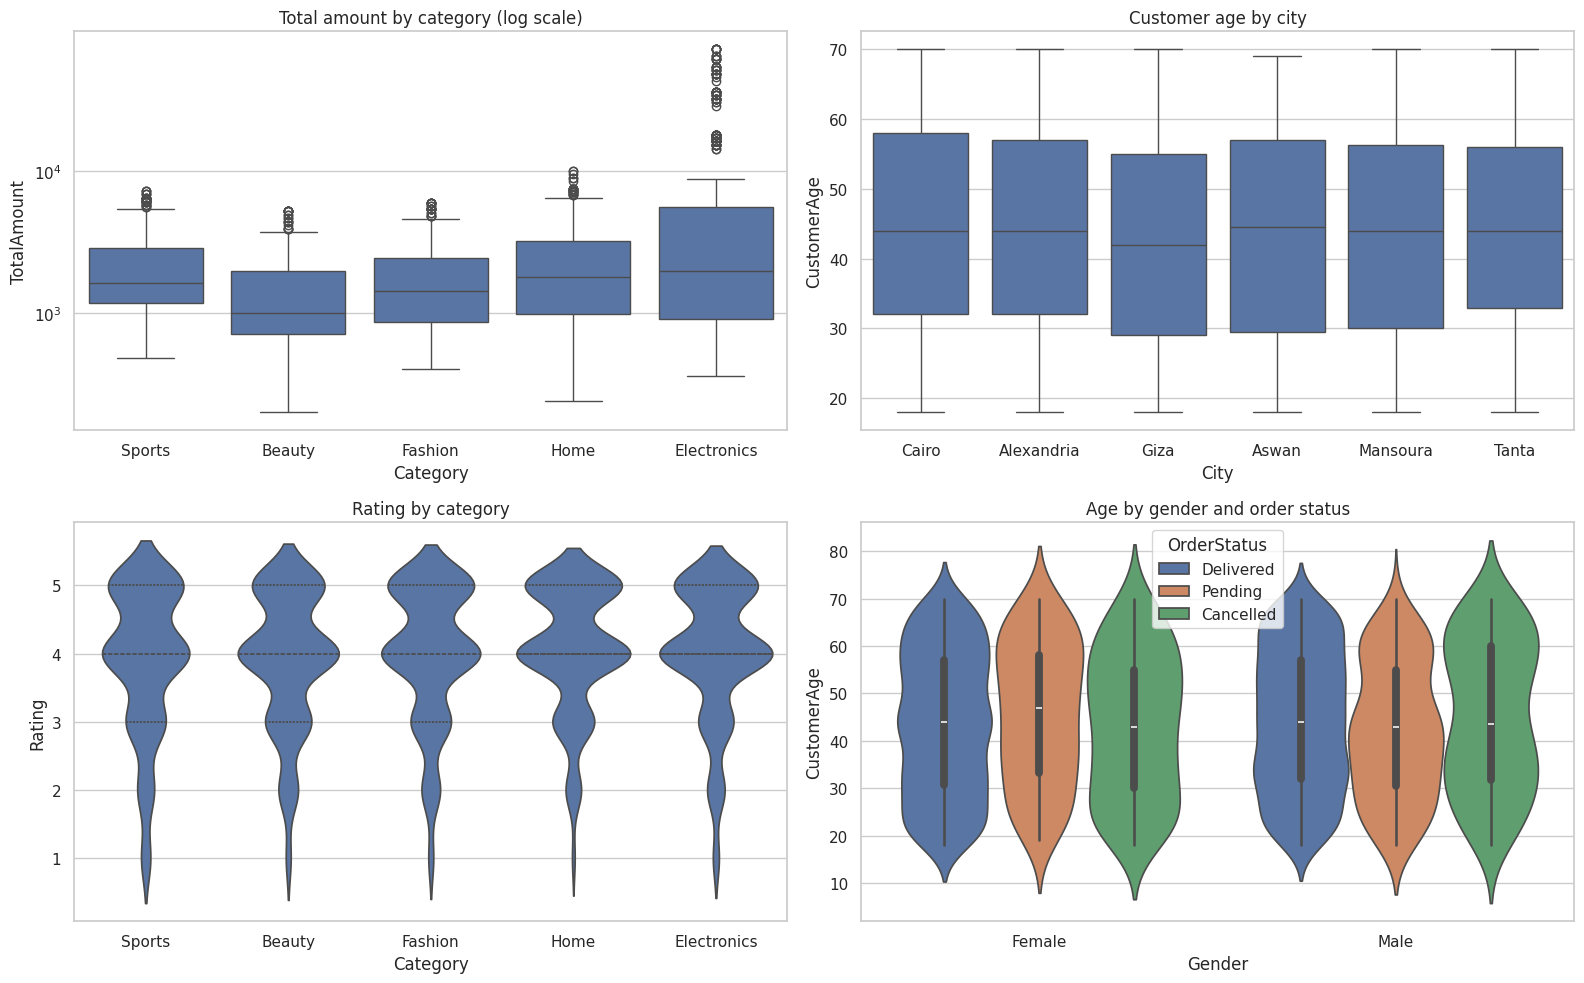

In [16]:
# box-whisker and violin plots
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=df, x="Category", y="TotalAmount", ax=ax[0, 0])
ax[0, 0].set_yscale("log")
ax[0, 0].set_title("Total amount by category (log scale)")

sns.boxplot(data=df, x="City", y="CustomerAge", ax=ax[0, 1])
ax[0, 1].set_title("Customer age by city")

sns.violinplot(data=rated, x="Category", y="Rating", inner="quartile", ax=ax[1, 0])
ax[1, 0].set_title("Rating by category")

sns.violinplot(data=df, x="Gender", y="CustomerAge", hue="OrderStatus", ax=ax[1, 1])
ax[1, 1].set_title("Age by gender and order status")
plt.tight_layout()
plt.show()

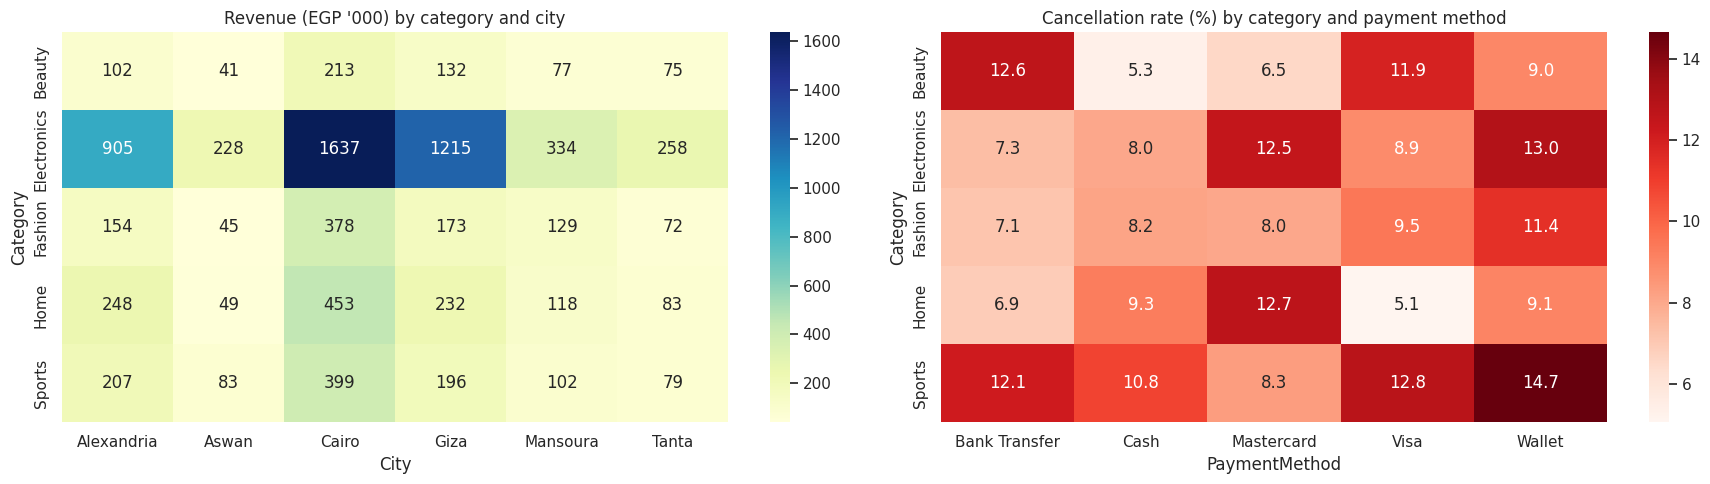

In [17]:
# heat maps
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
revenue_grid = df.pivot_table(index="Category", columns="City", values="TotalAmount", aggfunc="sum") / 1e3
sns.heatmap(revenue_grid, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Revenue (EGP '000) by category and city")

cancel_grid = df.pivot_table(index="Category", columns="PaymentMethod", values="IsCancelled", aggfunc="mean") * 100
sns.heatmap(cancel_grid, annot=True, fmt=".1f", cmap="Reds", ax=ax[1])
ax[1].set_title("Cancellation rate (%) by category and payment method")
plt.tight_layout()
plt.show()

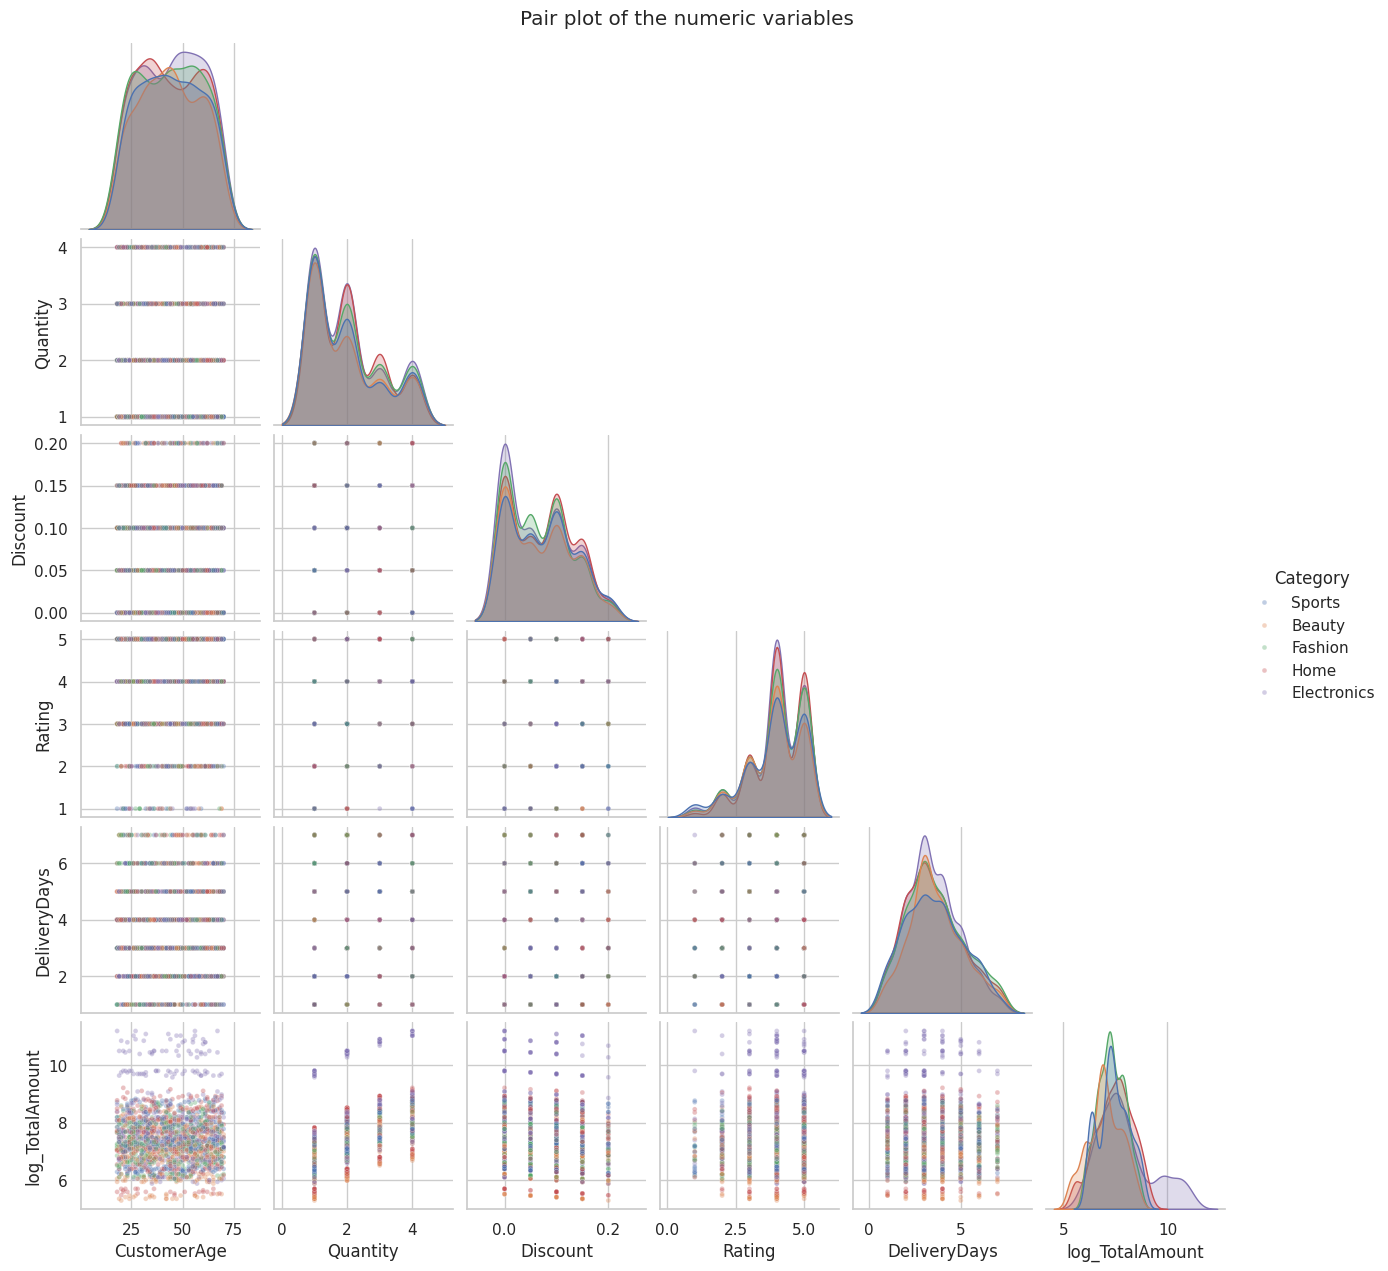

In [18]:
# pair plot (log of total amount so the big orders don't squash everything else)
pair_data = rated[["CustomerAge", "Quantity", "Discount", "TotalAmount", "Rating", "DeliveryDays", "Category"]].copy()
pair_data["log_TotalAmount"] = np.log(pair_data["TotalAmount"])
pair_data = pair_data.drop(columns="TotalAmount")

sns.pairplot(pair_data, hue="Category", corner=True, plot_kws={"alpha": 0.35, "s": 12}, height=2.1)
plt.suptitle("Pair plot of the numeric variables", y=1.01)
plt.show()

#### 4.3.2 Categorical data: bar plot, histogram, pie plot

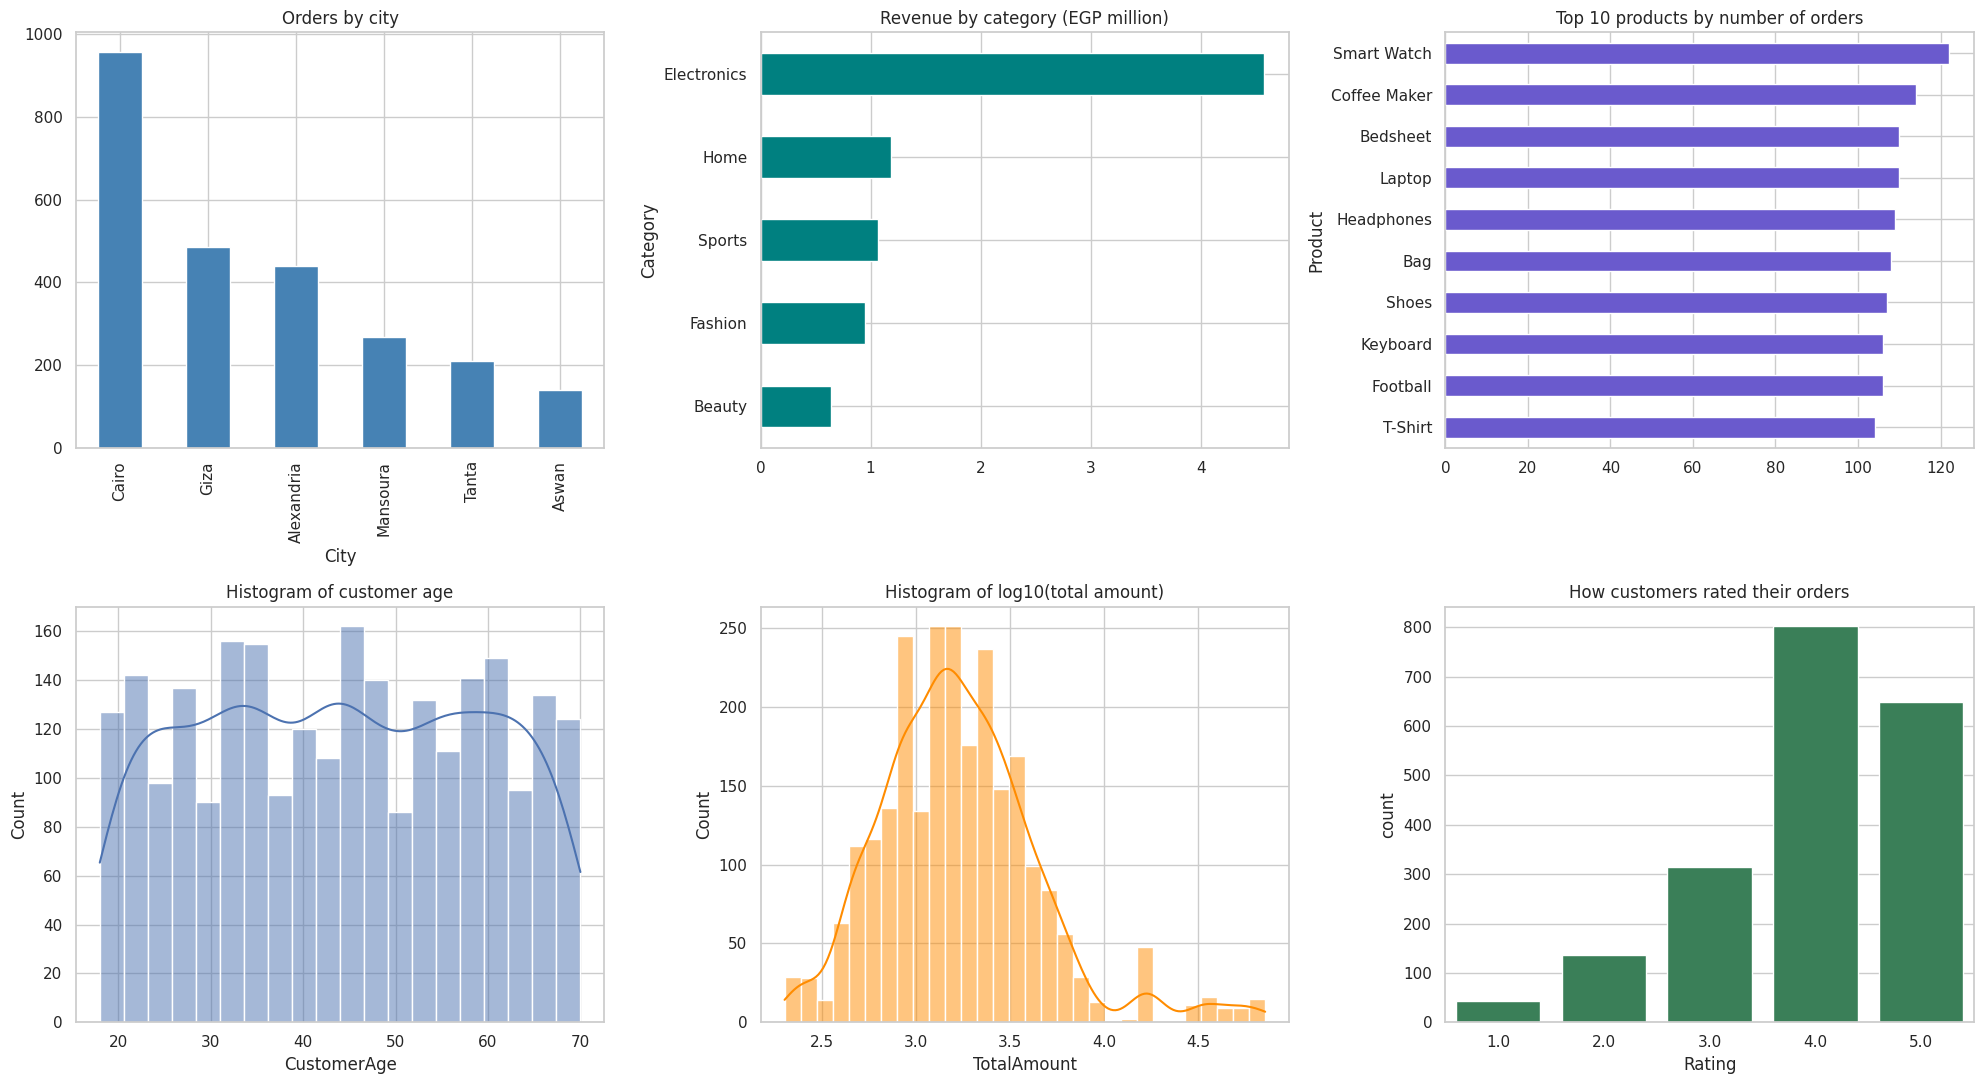

In [19]:
fig, ax = plt.subplots(2, 3, figsize=(20, 11))

df["City"].value_counts().plot.bar(ax=ax[0, 0], color="steelblue")
ax[0, 0].set_title("Orders by city")

(df.groupby("Category")["TotalAmount"].sum().sort_values() / 1e6).plot.barh(ax=ax[0, 1], color="teal")
ax[0, 1].set_title("Revenue by category (EGP million)")

df["Product"].value_counts().head(10).sort_values().plot.barh(ax=ax[0, 2], color="slateblue")
ax[0, 2].set_title("Top 10 products by number of orders")

sns.histplot(df["CustomerAge"], bins=20, kde=True, ax=ax[1, 0])
ax[1, 0].set_title("Histogram of customer age")

sns.histplot(np.log10(df["TotalAmount"]), bins=30, kde=True, color="darkorange", ax=ax[1, 1])
ax[1, 1].set_title("Histogram of log10(total amount)")

sns.countplot(data=rated, x="Rating", color="seagreen", ax=ax[1, 2])
ax[1, 2].set_title("How customers rated their orders")
plt.tight_layout()
plt.show()

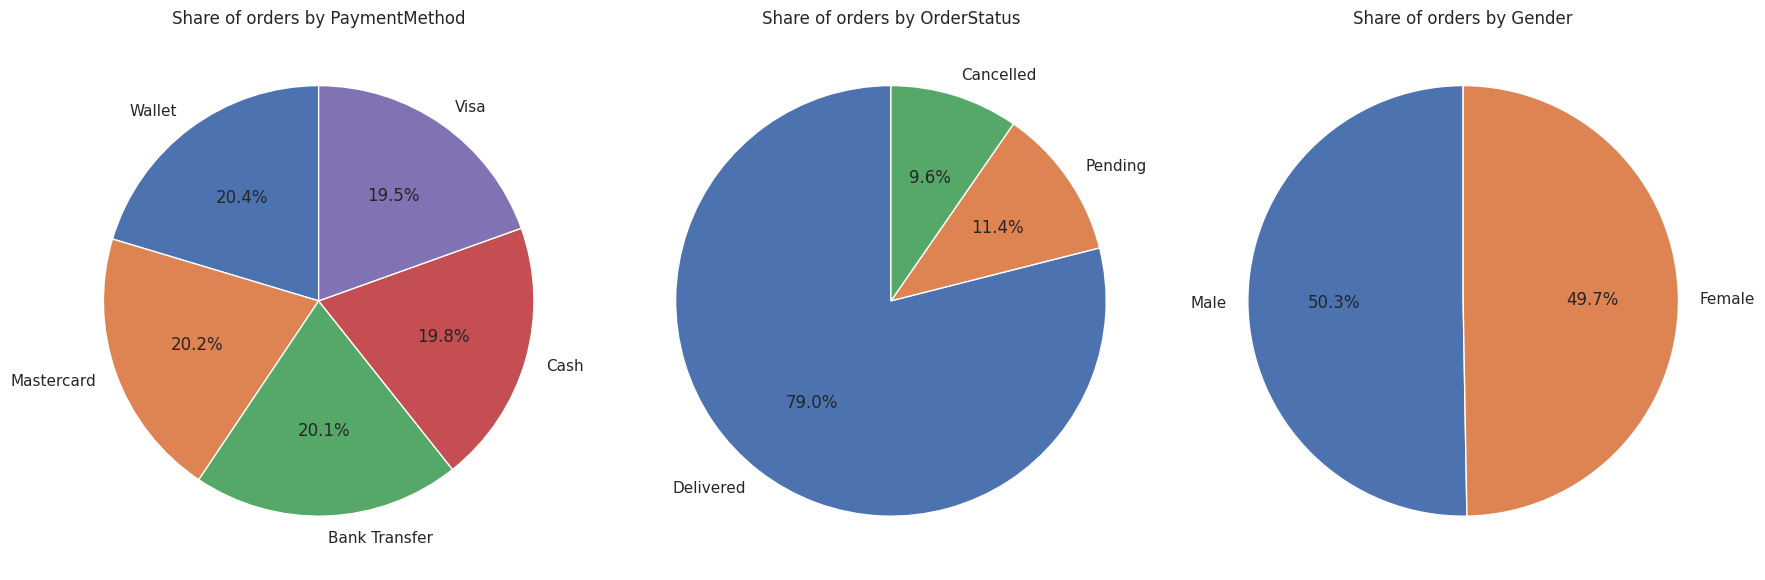

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for axis, col in zip(ax, ["PaymentMethod", "OrderStatus", "Gender"]):
    df[col].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=axis)
    axis.set_ylabel("")
    axis.set_title(f"Share of orders by {col}")
plt.tight_layout()
plt.show()

**What the charts show**

- Total amount rises in clear bands with unit price, one band per quantity. Age shows no pattern at all against order value.
- Monthly revenue stays between EGP 1.29 and 1.56 million with no clear upward or downward trend. January is the strongest month and April the weakest. Electronics is on top of the category lines every month.
- The box plots show Electronics orders sitting far above the other categories, while ages look much the same in every city. The rating violins look almost identical across categories.
- The revenue heat map is darkest for Electronics in Cairo. Cancellation rates move around between cells without any category or payment method standing out.
- The pair plot shows no strong link between rating and any other variable.
- In the bar and pie charts, Cairo leads on orders and Electronics leads on revenue. Payment methods and genders split almost evenly, and most orders are delivered. The age histogram is flat, and the log of total amount looks much closer to a bell shape than the raw amount does.

### 4.4 Inferential Statistics

We use a 5% significance level throughout. Every test result is also saved to one summary table at the end of this section.

In [21]:
ALPHA = 0.05
results = []

def save_test(test, variables, h0, stat, p):
    decision = "Reject H0" if p < ALPHA else "Do not reject H0"
    results.append({"Test": test, "Variables": variables, "H0": h0,
                    "Statistic": round(float(stat), 4), "p-value": float(p), "Decision": decision})
    print(f"{test:<30} {variables:<40} stat = {stat:>10.4f}   p = {p:.4g}   -> {decision}")

#### 4.4.1 Non-categorical data

**Confidence intervals (95%)**

In [22]:
def mean_ci(x, level=0.95):
    x = x.dropna()
    low, high = stats.t.interval(level, len(x) - 1, loc=x.mean(), scale=stats.sem(x))
    return x.mean(), low, high

ci = []
for col, data in [("TotalAmount", df), ("CustomerAge", df), ("Rating", rated), ("DeliveryDays", delivered)]:
    m, lo, hi = mean_ci(data[col])
    ci.append([f"Mean {col}", m, lo, hi])

for label, k, n in [("Share of cancelled orders", df["IsCancelled"].sum(), len(df)),
                    ("Share of ratings 4-5", rated["HighRating"].sum(), len(rated))]:
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    ci.append([label, k / n, lo, hi])

for cat in df["Category"].unique():
    m, lo, hi = mean_ci(df.loc[df["Category"] == cat, "TotalAmount"])
    ci.append([f"Mean TotalAmount - {cat}", m, lo, hi])

pd.DataFrame(ci, columns=["Parameter", "Estimate", "95% CI lower", "95% CI upper"])

,Parameter,Estimate,95% CI lower,95% CI upper
0,Mean TotalAmount,"3,366.3320","3,066.8141","3,665.8499"
1,Mean CustomerAge,43.9052,43.3151,44.4953
2,Mean Rating,3.9630,3.9190,4.0070
3,Mean DeliveryDays,3.5500,3.4823,3.6177
4,Share of cancelled orders,0.0964,0.0854,0.1086
5,Share of ratings 4-5,0.7452,0.7254,0.7641
6,Mean TotalAmount - Sports,"2,183.7551","2,042.1724","2,325.3379"
7,Mean TotalAmount - Beauty,"1,436.6368","1,329.7542","1,543.5194"
8,Mean TotalAmount - Fashion,"1,819.7222","1,711.7565","1,927.6880"
9,Mean TotalAmount - Home,"2,351.2127","2,184.6538","2,517.7716"


**Test of normality — Shapiro-Wilk, Kolmogorov-Smirnov, Anderson-Darling, Jarque-Bera**

In [23]:
normality = []
checks = [("TotalAmount", df["TotalAmount"]), ("log(TotalAmount)", np.log(df["TotalAmount"])),
          ("CustomerAge", df["CustomerAge"]), ("Rating", rated["Rating"]),
          ("DeliveryDays", delivered["DeliveryDays"].dropna())]

for name, x in checks:
    sw = stats.shapiro(x)
    ks = stats.kstest((x - x.mean()) / x.std(), "norm")      # KS on the standardised values
    ad = stats.anderson(x, dist="norm")
    jb = stats.jarque_bera(x)
    normality.append({"Variable": name,
                      "Shapiro W": sw.statistic, "Shapiro p": sw.pvalue,
                      "KS D": ks.statistic, "KS p": ks.pvalue,
                      "AD stat": ad.statistic, "AD 5% critical": ad.critical_values[2],
                      "JB stat": jb.statistic, "JB p": jb.pvalue})
    save_test("Shapiro-Wilk", name, "data is normal", sw.statistic, sw.pvalue)

pd.DataFrame(normality)

Shapiro-Wilk                   TotalAmount                              stat =     0.3326   p = 6.827e-70   -> Reject H0
Shapiro-Wilk                   log(TotalAmount)                         stat =     0.9531   p = 1.323e-27   -> Reject H0
Shapiro-Wilk                   CustomerAge                              stat =     0.9560   p = 7.898e-27   -> Reject H0
Shapiro-Wilk                   Rating                                   stat =     0.8361   p = 7.683e-41   -> Reject H0
Shapiro-Wilk                   DeliveryDays                             stat =     0.9407   p = 3.034e-27   -> Reject H0


,Variable,Shapiro W,Shapiro p,KS D,KS p,AD stat,AD 5% critical,JB stat,JB p
0,TotalAmount,0.3326,0.0000,0.3394,0.0000,543.7585,0.7520,"185,324.1892",0.0000
1,log(TotalAmount),0.9531,0.0000,0.0625,0.0000,19.1532,0.7520,674.9998,0.0000
2,CustomerAge,0.9560,0.0000,0.0711,0.0000,27.2372,0.7520,146.7615,0.0000
3,Rating,0.8361,0.0000,0.2602,0.0000,119.3110,0.7520,293.0728,0.0000
4,DeliveryDays,0.9407,0.0000,0.1765,0.0000,43.0912,0.7520,62.8260,0.0000


**Test of mean — t-tests and ANOVA**

In [24]:
male = df.loc[df["Gender"] == "Male", "TotalAmount"]
female = df.loc[df["Gender"] == "Female", "TotalAmount"]
t = stats.ttest_ind(male, female, equal_var=False)          # Welch's t-test, variances not assumed equal
save_test("Two-sample t-test (Welch)", "TotalAmount: male vs female", "means are equal", t.statistic, t.pvalue)

t = stats.ttest_1samp(rated["Rating"], 4.0)
save_test("One-sample t-test", "Rating vs 4.0", "mean rating = 4.0", t.statistic, t.pvalue)

r_male = rated.loc[rated["Gender"] == "Male", "Rating"]
r_female = rated.loc[rated["Gender"] == "Female", "Rating"]
t = stats.ttest_ind(r_male, r_female, equal_var=False)
save_test("Two-sample t-test (Welch)", "Rating: male vs female", "means are equal", t.statistic, t.pvalue)

# paired t-test: price before discount vs amount actually paid (discounted orders only)
disc_orders = df[df["Discount"] > 0]
gross = disc_orders["Quantity"] * disc_orders["UnitPrice"]
t = stats.ttest_rel(gross, disc_orders["TotalAmount"])
save_test("Paired t-test", "Gross vs net amount", "no difference", t.statistic, t.pvalue)

Two-sample t-test (Welch)      TotalAmount: male vs female              stat =    -0.3723   p = 0.7097   -> Do not reject H0
One-sample t-test              Rating vs 4.0                            stat =    -1.6491   p = 0.0993   -> Do not reject H0
Two-sample t-test (Welch)      Rating: male vs female                   stat =     1.3556   p = 0.1754   -> Do not reject H0
Paired t-test                  Gross vs net amount                      stat =    16.0206   p = 9.874e-54   -> Reject H0


In [25]:
# one-way ANOVA
f = stats.f_oneway(*[g["TotalAmount"] for _, g in df.groupby("Category")])
save_test("One-way ANOVA", "TotalAmount across categories", "all means equal", f.statistic, f.pvalue)

f = stats.f_oneway(*[g["Rating"] for _, g in rated.groupby("Category")])
save_test("One-way ANOVA", "Rating across categories", "all means equal", f.statistic, f.pvalue)

f = stats.f_oneway(*[g["TotalAmount"] for _, g in df.groupby("City")])
save_test("One-way ANOVA", "TotalAmount across cities", "all means equal", f.statistic, f.pvalue)

f = stats.f_oneway(*[g["Rating"] for _, g in rated.groupby("DeliveryDays")])
save_test("One-way ANOVA", "Rating across delivery days", "all means equal", f.statistic, f.pvalue)

# two-way ANOVA: does category matter, does gender matter, and do they interact?
two_way = sm.stats.anova_lm(smf.ols("np.log(TotalAmount) ~ C(Category) * C(Gender)", data=df).fit(), typ=2)
print("\nTwo-way ANOVA on log(TotalAmount):")
two_way

One-way ANOVA                  TotalAmount across categories            stat =    88.6986   p = 1.444e-70   -> Reject H0
One-way ANOVA                  Rating across categories                 stat =     2.0441   p = 0.08577   -> Do not reject H0
One-way ANOVA                  TotalAmount across cities                stat =     1.4814   p = 0.1925   -> Do not reject H0
One-way ANOVA                  Rating across delivery days              stat =     1.1819   p = 0.313   -> Do not reject H0

Two-way ANOVA on log(TotalAmount):


,sum_sq,df,F,PR(>F)
C(Category),259.2327,4.0000,75.3379,0.0000
C(Gender),0.5347,1.0000,0.6215,0.4305
C(Category):C(Gender),2.2846,4.0000,0.6639,0.6170
Residual,"2,141.9804","2,490.0000",NaN,NaN


**Test of variance — F-test, Levene, Bartlett**

In [26]:
# F-test for two variances (log amount, male vs female)
log_m, log_f = np.log(male), np.log(female)
F = log_m.var(ddof=1) / log_f.var(ddof=1)
df1, df2 = len(log_m) - 1, len(log_f) - 1
p = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
save_test("F-test", "log(TotalAmount): male vs female", "variances equal", F, p)

lev = stats.levene(*[g["TotalAmount"] for _, g in df.groupby("Category")])
save_test("Levene", "TotalAmount across categories", "variances equal", lev.statistic, lev.pvalue)

bart = stats.bartlett(*[np.log(g["TotalAmount"]) for _, g in df.groupby("Category")])
save_test("Bartlett", "log(TotalAmount) across categories", "variances equal", bart.statistic, bart.pvalue)

lev = stats.levene(*[g["Rating"] for _, g in rated.groupby("Category")])
save_test("Levene", "Rating across categories", "variances equal", lev.statistic, lev.pvalue)

F-test                         log(TotalAmount): male vs female         stat =     0.9553   p = 0.4187   -> Do not reject H0
Levene                         TotalAmount across categories            stat =    87.2784   p = 1.716e-69   -> Reject H0
Bartlett                       log(TotalAmount) across categories       stat =   384.8638   p = 5.181e-82   -> Reject H0
Levene                         Rating across categories                 stat =     1.5892   p = 0.1745   -> Do not reject H0


**Test of correlation — t-test on Pearson's r**

In [27]:
def correlation_t(x, y, label):
    r = np.corrcoef(x, y)[0, 1]
    n = len(x)
    t = r * np.sqrt((n - 2) / (1 - r ** 2))
    p = 2 * (1 - stats.t.cdf(abs(t), n - 2))
    save_test("Correlation t-test", f"{label} (r = {r:.3f})", "no correlation", t, p)

with_days = rated.dropna(subset=["DeliveryDays"])
correlation_t(with_days["DeliveryDays"], with_days["Rating"], "DeliveryDays vs Rating")
correlation_t(rated["Discount"], rated["Rating"], "Discount vs Rating")
correlation_t(df["CustomerAge"], df["TotalAmount"], "Age vs TotalAmount")
correlation_t(df["Quantity"], df["TotalAmount"], "Quantity vs TotalAmount")

Correlation t-test             DeliveryDays vs Rating (r = 0.020)       stat =     0.8867   p = 0.3753   -> Do not reject H0
Correlation t-test             Discount vs Rating (r = -0.002)          stat =    -0.0951   p = 0.9242   -> Do not reject H0
Correlation t-test             Age vs TotalAmount (r = -0.003)          stat =    -0.1719   p = 0.8636   -> Do not reject H0
Correlation t-test             Quantity vs TotalAmount (r = 0.237)      stat =    12.1850   p = 0   -> Reject H0


**Non-parametric tests — Mann-Whitney, Wilcoxon, Kruskal-Wallis, Friedman**

The normality tests above rejected normality for every variable, so we repeat the key comparisons with tests that do not assume a normal distribution.

In [28]:
u = stats.mannwhitneyu(male, female)
save_test("Mann-Whitney U", "TotalAmount: male vs female", "same distribution", u.statistic, u.pvalue)

w = stats.wilcoxon(gross, disc_orders["TotalAmount"])
save_test("Wilcoxon signed-rank", "Gross vs net amount", "no difference", w.statistic, w.pvalue)

h = stats.kruskal(*[g["TotalAmount"] for _, g in df.groupby("Category")])
save_test("Kruskal-Wallis", "TotalAmount across categories", "same distribution", h.statistic, h.pvalue)

# Friedman: the six months act as blocks and the five categories are compared within each month
month_cat = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category",
                                                         values="TotalAmount", aggfunc="sum")
fr = stats.friedmanchisquare(*[month_cat[c] for c in month_cat.columns])
save_test("Friedman", "Monthly revenue across categories", "same distribution", fr.statistic, fr.pvalue)

Mann-Whitney U                 TotalAmount: male vs female              stat = 804632.5000   p = 0.1946   -> Do not reject H0
Wilcoxon signed-rank           Gross vs net amount                      stat =     0.0000   p = 2.447e-266   -> Reject H0
Kruskal-Wallis                 TotalAmount across categories            stat =   163.7779   p = 2.262e-34   -> Reject H0
Friedman                       Monthly revenue across categories        stat =    20.4000   p = 0.0004163   -> Reject H0


#### 4.4.2 Categorical data

**Test of proportion — z-test and Chi-square**

In [29]:
cancel_by_gender = df.groupby("Gender")["IsCancelled"].agg(["sum", "count"])
cancel_by_gender["rate"] = cancel_by_gender["sum"] / cancel_by_gender["count"]
display(cancel_by_gender)

z, p = proportions_ztest(cancel_by_gender["sum"].values, cancel_by_gender["count"].values)
save_test("Two-proportion z-test", "Cancel rate: male vs female", "proportions equal", z, p)

z, p = proportions_ztest(df["IsCancelled"].sum(), len(df), value=0.10)
save_test("One-proportion z-test", "Cancel rate vs 10%", "proportion = 0.10", z, p)

share_table = pd.crosstab(rated["Category"], rated["HighRating"])
chi = stats.chi2_contingency(share_table)
save_test("Chi-square (proportions)", "Share of 4-5 ratings by category", "proportions equal", chi.statistic, chi.pvalue)

,sum,count,rate
Gender,,,
Female,133,1243,0.1070
Male,108,1257,0.0859


Two-proportion z-test          Cancel rate: male vs female              stat =     1.7856   p = 0.07416   -> Do not reject H0
One-proportion z-test          Cancel rate vs 10%                       stat =    -0.6099   p = 0.5419   -> Do not reject H0
Chi-square (proportions)       Share of 4-5 ratings by category         stat =     7.9623   p = 0.09297   -> Do not reject H0


**Chi-square test — goodness of fit and test of independence**

In [30]:
# goodness of fit: are the levels equally common?
for col in ["Category", "PaymentMethod", "Gender"]:
    gof = stats.chisquare(df[col].value_counts())
    save_test("Chi-square goodness of fit", f"{col} equally likely", "uniform distribution", gof.statistic, gof.pvalue)

# goodness of fit of ratings against a target mix of 10/10/20/30/30 %
observed = rated["Rating"].value_counts().sort_index()
expected = np.array([0.10, 0.10, 0.20, 0.30, 0.30]) * observed.sum()
gof = stats.chisquare(observed, expected)
save_test("Chi-square goodness of fit", "Rating vs 10/10/20/30/30 target", "fits the target", gof.statistic, gof.pvalue)

# test of independence
pairs = [("Category", "OrderStatus", df), ("PaymentMethod", "OrderStatus", df), ("Gender", "Category", df),
         ("City", "PaymentMethod", df), ("AgeGroup", "Category", df), ("Category", "Rating", rated)]
for a, b, data in pairs:
    res = stats.chi2_contingency(pd.crosstab(data[a], data[b]))
    save_test("Chi-square independence", f"{a} x {b}", "independent", res.statistic, res.pvalue)

pd.crosstab(df["Category"], df["OrderStatus"], margins=True)

Chi-square goodness of fit     Category equally likely                  stat =    10.4680   p = 0.03324   -> Reject H0
Chi-square goodness of fit     PaymentMethod equally likely             stat =     0.5800   p = 0.9653   -> Do not reject H0
Chi-square goodness of fit     Gender equally likely                    stat =     0.0784   p = 0.7795   -> Do not reject H0
Chi-square goodness of fit     Rating vs 10/10/20/30/30 target          stat =   236.4575   p = 5.374e-50   -> Reject H0
Chi-square independence        Category x OrderStatus                   stat =     5.9517   p = 0.6526   -> Do not reject H0
Chi-square independence        PaymentMethod x OrderStatus              stat =    10.0135   p = 0.2641   -> Do not reject H0
Chi-square independence        Gender x Category                        stat =     1.5974   p = 0.8093   -> Do not reject H0
Chi-square independence        City x PaymentMethod                     stat =    12.1377   p = 0.9113   -> Do not reject H0
Chi-square

OrderStatus,Cancelled,Delivered,Pending,All
Category,,,,
Beauty,40,354,52,446
Electronics,53,427,61,541
Fashion,46,410,66,522
Home,44,409,50,503
Sports,58,374,56,488
All,241,1974,285,2500


**Non-parametric tests on ordinal data (Rating)**

In [31]:
u = stats.mannwhitneyu(r_male, r_female)
save_test("Mann-Whitney U", "Rating: male vs female", "same distribution", u.statistic, u.pvalue)

w = stats.wilcoxon(rated["Rating"] - 4)
save_test("Wilcoxon signed-rank", "Rating vs median 4", "median = 4", w.statistic, w.pvalue)

h = stats.kruskal(*[g["Rating"] for _, g in rated.groupby("Category")])
save_test("Kruskal-Wallis", "Rating across categories", "same distribution", h.statistic, h.pvalue)

h = stats.kruskal(*[g["Rating"] for _, g in rated.groupby("PaymentMethod")])
save_test("Kruskal-Wallis", "Rating across payment methods", "same distribution", h.statistic, h.pvalue)

month_orders = df.dropna(subset=["OrderMonth"]).pivot_table(index="OrderMonth", columns="Category",
                                                            values="OrderID", aggfunc="count")
fr = stats.friedmanchisquare(*[month_orders[c] for c in month_orders.columns])
save_test("Friedman", "Monthly order count across categories", "same distribution", fr.statistic, fr.pvalue)

Mann-Whitney U                 Rating: male vs female                   stat = 494466.5000   p = 0.0761   -> Do not reject H0
Wilcoxon signed-rank           Rating vs median 4                       stat = 313142.5000   p = 0.1489   -> Do not reject H0
Kruskal-Wallis                 Rating across categories                 stat =     6.6558   p = 0.1552   -> Do not reject H0
Kruskal-Wallis                 Rating across payment methods            stat =     2.8373   p = 0.5854   -> Do not reject H0
Friedman                       Monthly order count across categories    stat =     5.4790   p = 0.2416   -> Do not reject H0


In [32]:
# all tests in one place
test_table = pd.DataFrame(results)
test_table["p-value"] = test_table["p-value"].map(lambda p: f"{p:.4g}")
print(len(test_table), "tests,", (test_table["Decision"] == "Reject H0").sum(), "significant at 5%")
test_table

43 tests, 15 significant at 5%


,Test,Variables,H0,Statistic,p-value,Decision
0,Shapiro-Wilk,TotalAmount,data is normal,0.3326,6.827e-70,Reject H0
1,Shapiro-Wilk,log(TotalAmount),data is normal,0.9531,1.323e-27,Reject H0
2,Shapiro-Wilk,CustomerAge,data is normal,0.9560,7.898e-27,Reject H0
3,Shapiro-Wilk,Rating,data is normal,0.8361,7.683e-41,Reject H0
4,Shapiro-Wilk,DeliveryDays,data is normal,0.9407,3.034e-27,Reject H0
5,Two-sample t-test (Welch),TotalAmount: male vs female,means are equal,-0.3723,0.7097,Do not reject H0
6,One-sample t-test,Rating vs 4.0,mean rating = 4.0,-1.6491,0.0993,Do not reject H0
7,Two-sample t-test (Welch),Rating: male vs female,means are equal,1.3556,0.1754,Do not reject H0
8,Paired t-test,Gross vs net amount,no difference,16.0206,9.874e-54,Reject H0
9,One-way ANOVA,TotalAmount across categories,all means equal,88.6986,1.444e-70,Reject H0


**What the tests say**

- *Confidence intervals:* the mean order value is EGP 3,366 (95% CI 3,067 to 3,666). The mean rating is 3.96 (3.92 to 4.01) and 9.6% of orders are cancelled (8.5% to 10.9%). Electronics' mean order of EGP 8,460 (7,185 to 9,735) does not overlap with any other category.
- *Normality:* all four tests reject normality for every variable, even for log(TotalAmount). This is why the non-parametric tests were also run.
- *Means:* order value differs strongly between categories (ANOVA F = 88.7, p < 0.001), but not between men and women (p = 0.71) or between cities (p = 0.19). The two-way ANOVA shows no category x gender interaction (p = 0.62). Mean rating is not significantly different from 4.0 (p = 0.10), and it does not change with delivery days (p = 0.31). The paired test confirms that discounts do reduce the amount paid (p < 0.001).
- *Variances:* order values are spread very differently across categories (Levene and Bartlett p < 0.001), but men and women have similar spread (F-test p = 0.42).
- *Correlation:* only quantity is significantly correlated with order value (r = 0.24). Delivery days, discount and age show no significant link with rating or spending.
- *Non-parametric:* the Mann-Whitney, Wilcoxon and Kruskal-Wallis results agree with the t-tests and ANOVA above. The Friedman test shows that categories differ consistently in monthly revenue (p < 0.001), but not in monthly order counts (p = 0.24).
- *Proportions:* the cancellation rate is in line with a 10% benchmark (p = 0.54) and is similar for men and women (p = 0.07).
- *Chi-square:* categories are not equally popular (p = 0.03), but payment methods are (p = 0.97). Order status is independent of category (p = 0.65) and payment method (p = 0.26), and rating is independent of category (p = 0.32).

### 4.5 Causal Analysis — Regression

#### 4.5.1 Non-categorical data

**(a) Multiple linear regression (cross-sectional data).** We model log(TotalAmount), because the amount is heavily skewed and the effects are multiplicative.

In [33]:
model_1 = smf.ols("np.log(TotalAmount) ~ Quantity + np.log(UnitPrice) + Discount + CustomerAge", data=df).fit()
print(model_1.summary())

                             OLS Regression Results                            
Dep. Variable:     np.log(TotalAmount)   R-squared:                       0.989
Model:                             OLS   Adj. R-squared:                  0.989
Method:                  Least Squares   F-statistic:                 5.477e+04
Date:                 Sun, 27 Sep 2026   Prob (F-statistic):               0.00
Time:                         19:35:43   Log-Likelihood:                 2109.6
No. Observations:                 2500   AIC:                            -4209.
Df Residuals:                     2495   BIC:                            -4180.
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -0.4016

In [34]:
# the same model in plain EGP, which is easier to read
model_1b = smf.ols("TotalAmount ~ Quantity + UnitPrice + Discount + CustomerAge", data=df).fit()
print(f"R-squared = {model_1b.rsquared:.3f}, adjusted R-squared = {model_1b.rsquared_adj:.3f}")
pd.DataFrame({"coefficient": model_1b.params, "p-value": model_1b.pvalues})

R-squared = 0.784, adjusted R-squared = 0.783


,coefficient,p-value
Intercept,"-3,153.9109",0.0000
Quantity,"1,733.0423",0.0000
UnitPrice,1.8513,0.0000
Discount,"-3,522.5406",0.0023
CustomerAge,-1.2422,0.7926


**(b) Regression on time-series data** — daily revenue and daily orders against a time trend.

Revenue trend: -35.4 EGP per day (p = 0.438, R-squared = 0.003)
Orders model with weekday effects: R-squared = 0.050, F-test p = 0.260



                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  15.0702      0.820     18.384      0.000      13.452      16.688
C(Weekday)[T.Monday]       -1.4768      0.973     -1.517      0.131      -3.398       0.444
C(Weekday)[T.Saturday]     -0.1846      0.973     -0.190      0.850      -2.105       1.736
C(Weekday)[T.Sunday]       -0.4076      0.973     -0.419      0.676      -2.328       1.513
C(Weekday)[T.Thursday]     -1.6231      0.973     -1.668      0.097      -3.544       0.298
C(Weekday)[T.Tuesday]       0.0593      0.983      0.060      0.952      -1.881       1.999
C(Weekday)[T.Wednesday]     0.0270      0.983      0.027      0.978      -1.913       1.967
t                          -0.0077      0.005     -1.539      0.126      -0.018       0.002


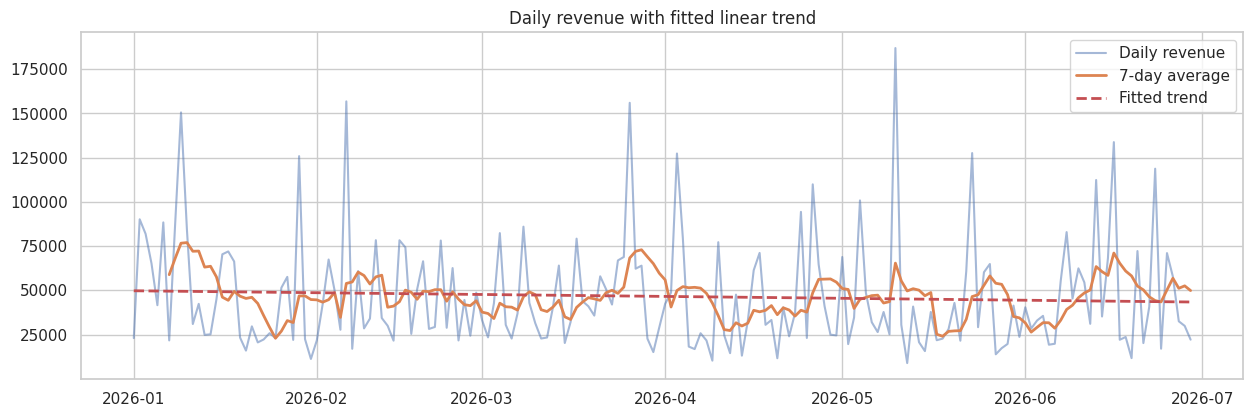

In [35]:
daily = (df.dropna(subset=["OrderDate"])
           .set_index("OrderDate")
           .resample("D")
           .agg(Revenue=("TotalAmount", "sum"), Orders=("OrderID", "count"))
           .reset_index())
daily["t"] = np.arange(len(daily))                      # day number 0, 1, 2 ...
daily["Weekday"] = daily["OrderDate"].dt.day_name()

trend_rev = smf.ols("Revenue ~ t", data=daily).fit()
trend_orders = smf.ols("Orders ~ t + C(Weekday)", data=daily).fit()

print(f"Revenue trend: {trend_rev.params['t']:.1f} EGP per day (p = {trend_rev.pvalues['t']:.3f}, R-squared = {trend_rev.rsquared:.3f})")
print(f"Orders model with weekday effects: R-squared = {trend_orders.rsquared:.3f}, F-test p = {trend_orders.f_pvalue:.3f}\n")
print(trend_orders.summary().tables[1])

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(daily["OrderDate"], daily["Revenue"], alpha=0.5, label="Daily revenue")
ax.plot(daily["OrderDate"], daily["Revenue"].rolling(7).mean(), linewidth=2, label="7-day average")
ax.plot(daily["OrderDate"], trend_rev.fittedvalues, "r--", linewidth=2, label="Fitted trend")
ax.set_title("Daily revenue with fitted linear trend")
ax.legend()
plt.show()

**(c) Polynomial regression (cross-sectional data)** — does rating rise or fall in a curve with delivery time? Does spending follow a curve with age?

   Degree  R-squared  Adj R-squared        AIC  F-test p
0       1     0.0004        -0.0001 5,420.2467    0.3753
1       2     0.0021         0.0011 5,418.9748    0.1318
2       3     0.0021         0.0006 5,420.9325    0.2515
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.7311      0.116     32.129      0.000       3.503       3.959
DeliveryDays             0.1269      0.065      1.964      0.050       0.000       0.254
I(DeliveryDays ** 2)    -0.0148      0.008     -1.808      0.071      -0.031       0.001

log(TotalAmount) ~ Age + Age^2: R-squared = 0.0000, F-test p = 0.982


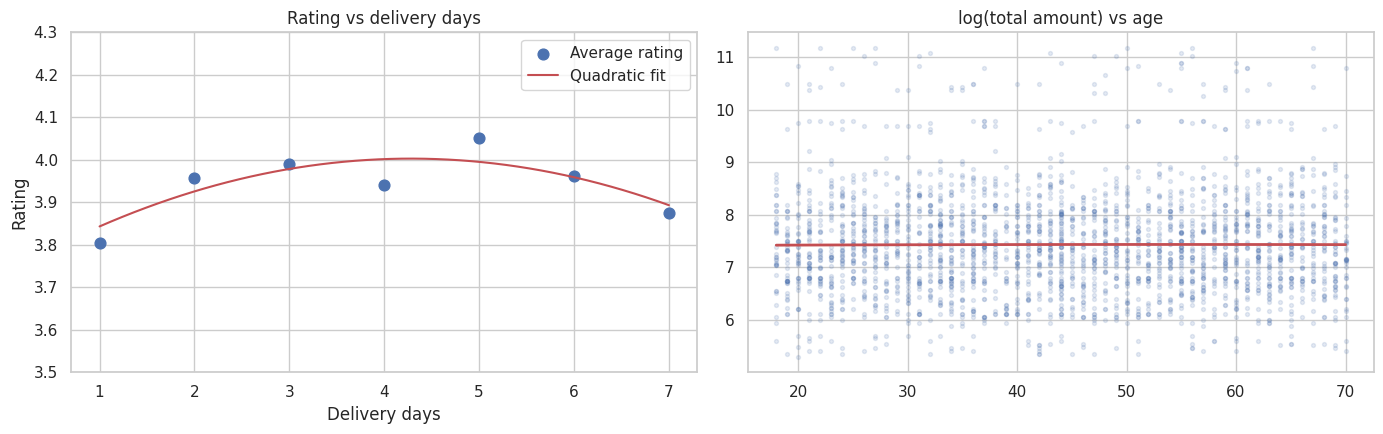

In [36]:
with_days = rated.dropna(subset=["DeliveryDays"])
poly_1 = smf.ols("Rating ~ DeliveryDays", data=with_days).fit()
poly_2 = smf.ols("Rating ~ DeliveryDays + I(DeliveryDays**2)", data=with_days).fit()
poly_3 = smf.ols("Rating ~ DeliveryDays + I(DeliveryDays**2) + I(DeliveryDays**3)", data=with_days).fit()

print(pd.DataFrame({"Degree": [1, 2, 3],
                    "R-squared": [poly_1.rsquared, poly_2.rsquared, poly_3.rsquared],
                    "Adj R-squared": [poly_1.rsquared_adj, poly_2.rsquared_adj, poly_3.rsquared_adj],
                    "AIC": [poly_1.aic, poly_2.aic, poly_3.aic],
                    "F-test p": [poly_1.f_pvalue, poly_2.f_pvalue, poly_3.f_pvalue]}))
print(poly_2.summary().tables[1])

poly_age = smf.ols("np.log(TotalAmount) ~ CustomerAge + I(CustomerAge**2)", data=df).fit()
print(f"\nlog(TotalAmount) ~ Age + Age^2: R-squared = {poly_age.rsquared:.4f}, F-test p = {poly_age.f_pvalue:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
grid = pd.DataFrame({"DeliveryDays": np.linspace(1, 7, 50)})
avg = with_days.groupby("DeliveryDays")["Rating"].mean()
ax[0].scatter(avg.index, avg.values, s=60, label="Average rating")
ax[0].plot(grid["DeliveryDays"], poly_2.predict(grid), "r-", label="Quadratic fit")
ax[0].set_ylim(3.5, 4.3)
ax[0].set_xlabel("Delivery days")
ax[0].set_ylabel("Rating")
ax[0].legend()
ax[0].set_title("Rating vs delivery days")

age_grid = pd.DataFrame({"CustomerAge": np.linspace(18, 70, 60)})
ax[1].scatter(df["CustomerAge"], np.log(df["TotalAmount"]), alpha=0.15, s=8)
ax[1].plot(age_grid["CustomerAge"], poly_age.predict(age_grid), "r-", linewidth=2)
ax[1].set_title("log(total amount) vs age")
plt.tight_layout()
plt.show()

#### 4.5.2 Categorical data

**(d) Regression with categorical variables** (dummy variables; the base level is in brackets)

In [37]:
model_cat = smf.ols("np.log(TotalAmount) ~ C(Category, Treatment('Beauty')) + C(City, Treatment('Cairo'))"
                    " + C(Gender) + C(PaymentMethod) + Quantity + Discount", data=df).fit()
print(model_cat.summary().tables[0])
print(model_cat.summary().tables[1])

                             OLS Regression Results                            
Dep. Variable:     np.log(TotalAmount)   R-squared:                       0.370
Model:                             OLS   Adj. R-squared:                  0.366
Method:                  Least Squares   F-statistic:                     91.25
Date:                 Sun, 27 Sep 2026   Prob (F-statistic):          3.87e-235
Time:                         19:35:44   Log-Likelihood:                -2920.4
No. Observations:                 2500   AIC:                             5875.
Df Residuals:                     2483   BIC:                             5974.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [38]:
model_rating = smf.ols("Rating ~ C(Category) + C(PaymentMethod) + C(Gender) + C(AgeGroup) + DeliveryDays + Discount",
                       data=with_days).fit()
print(f"Rating model: R-squared = {model_rating.rsquared:.4f}, F = {model_rating.fvalue:.3f}, p = {model_rating.f_pvalue:.4f}")
sm.stats.anova_lm(model_rating, typ=2)

Rating model: R-squared = 0.0081, F = 0.975, p = 0.4815


,sum_sq,df,F,PR(>F)
C(Category),8.9598,4.0000,2.2823,0.0584
C(PaymentMethod),1.5755,4.0000,0.4013,0.8078
C(Gender),2.0685,1.0000,2.1076,0.1467
C(AgeGroup),1.9792,5.0000,0.4033,0.8468
DeliveryDays,0.8830,1.0000,0.8997,0.3430
Discount,0.0007,1.0000,0.0007,0.9782
Residual,"1,869.6810","1,905.0000",NaN,NaN


**(e) Logistic regression** — what affects (i) the chance of a 4-5 star rating and (ii) the chance of an order being cancelled?

In [39]:
logit_rating = smf.logit("HighRating ~ DeliveryDays + Discount + CustomerAge + C(Category) + C(Gender) + C(PaymentMethod)",
                         data=with_days).fit(disp=0)
print(logit_rating.summary().tables[1])
print(f"McFadden pseudo R-squared = {logit_rating.prsquared:.4f} | LLR p-value = {logit_rating.llr_pvalue:.4f}")
pd.DataFrame({"Odds ratio": np.exp(logit_rating.params), "p-value": logit_rating.pvalues})

                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          0.8060      0.266      3.033      0.002       0.285       1.327
C(Category)[T.Electronics]         0.3071      0.167      1.845      0.065      -0.019       0.633
C(Category)[T.Fashion]             0.1575      0.165      0.956      0.339      -0.165       0.480
C(Category)[T.Home]                0.3892      0.170      2.292      0.022       0.056       0.722
C(Category)[T.Sports]             -0.0031      0.166     -0.019      0.985      -0.328       0.322
C(Gender)[T.Male]                  0.1107      0.105      1.053      0.292      -0.095       0.317
C(PaymentMethod)[T.Cash]          -0.2108      0.166     -1.267      0.205      -0.537       0.115
C(PaymentMethod)[T.Mastercard]    -0.1978      0.167     -1.183      0.237      -0.526       0.130
C(PaymentM

,Odds ratio,p-value
Intercept,2.2388,0.0024
C(Category)[T.Electronics],1.3595,0.0651
C(Category)[T.Fashion],1.1706,0.3392
C(Category)[T.Home],1.4758,0.0219
C(Category)[T.Sports],0.9969,0.9850
C(Gender)[T.Male],1.1171,0.2923
C(PaymentMethod)[T.Cash],0.8099,0.2053
C(PaymentMethod)[T.Mastercard],0.8205,0.2369
C(PaymentMethod)[T.Visa],0.7705,0.1221
C(PaymentMethod)[T.Wallet],0.8902,0.4882


In [40]:
logit_cancel = smf.logit("IsCancelled ~ Discount + CustomerAge + np.log(TotalAmount) + C(Category) + C(PaymentMethod) + C(Gender)",
                         data=df).fit(disp=0)
print(logit_cancel.summary().tables[1])
print(f"McFadden pseudo R-squared = {logit_cancel.prsquared:.4f} | LLR p-value = {logit_cancel.llr_pvalue:.4f}")
pd.DataFrame({"Odds ratio": np.exp(logit_cancel.params), "p-value": logit_cancel.pvalues})

                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                         -1.4061      0.607     -2.315      0.021      -2.597      -0.216
C(Category)[T.Electronics]         0.2033      0.231      0.881      0.378      -0.249       0.655
C(Category)[T.Fashion]             0.0144      0.228      0.063      0.950      -0.433       0.462
C(Category)[T.Home]                0.0314      0.232      0.135      0.892      -0.423       0.486
C(Category)[T.Sports]              0.3737      0.221      1.692      0.091      -0.059       0.806
C(PaymentMethod)[T.Cash]          -0.0976      0.226     -0.433      0.665      -0.540       0.345
C(PaymentMethod)[T.Mastercard]     0.0743      0.216      0.343      0.731      -0.350       0.499
C(PaymentMethod)[T.Visa]           0.0423      0.220      0.192      0.847      -0.389       0.473
C(PaymentM

,Odds ratio,p-value
Intercept,0.2451,0.0206
C(Category)[T.Electronics],1.2254,0.3782
C(Category)[T.Fashion],1.0145,0.9496
C(Category)[T.Home],1.0319,0.8924
C(Category)[T.Sports],1.4531,0.0906
C(PaymentMethod)[T.Cash],0.9070,0.6652
C(PaymentMethod)[T.Mastercard],1.0772,0.7313
C(PaymentMethod)[T.Visa],1.0432,0.8475
C(PaymentMethod)[T.Wallet],1.3038,0.2029
C(Gender)[T.Male],0.7730,0.0596


In [41]:
# quick comparison of all the models
pd.DataFrame([
    ["Multiple linear (log)", "log(TotalAmount)", model_1.rsquared, model_1.f_pvalue],
    ["Multiple linear (EGP)", "TotalAmount", model_1b.rsquared, model_1b.f_pvalue],
    ["Time series - trend", "Daily revenue", trend_rev.rsquared, trend_rev.f_pvalue],
    ["Time series - trend + weekday", "Daily orders", trend_orders.rsquared, trend_orders.f_pvalue],
    ["Polynomial (degree 2)", "Rating", poly_2.rsquared, poly_2.f_pvalue],
    ["Polynomial (degree 2)", "log(TotalAmount)", poly_age.rsquared, poly_age.f_pvalue],
    ["With categorical variables", "log(TotalAmount)", model_cat.rsquared, model_cat.f_pvalue],
    ["With categorical variables", "Rating", model_rating.rsquared, model_rating.f_pvalue],
    ["Logistic", "High rating (0/1)", logit_rating.prsquared, logit_rating.llr_pvalue],
    ["Logistic", "Cancelled (0/1)", logit_cancel.prsquared, logit_cancel.llr_pvalue],
], columns=["Model", "Dependent variable", "R-squared / pseudo R-squared", "Model p-value"])

,Model,Dependent variable,R-squared / pseudo R-squared,Model p-value
0,Multiple linear (log),log(TotalAmount),0.9887,0.0000
1,Multiple linear (EGP),TotalAmount,0.7838,0.0000
2,Time series - trend,Daily revenue,0.0034,0.4375
3,Time series - trend + weekday,Daily orders,0.0497,0.2599
4,Polynomial (degree 2),Rating,0.0021,0.1318
5,Polynomial (degree 2),log(TotalAmount),0.0000,0.9825
6,With categorical variables,log(TotalAmount),0.3703,0.0000
7,With categorical variables,Rating,0.0081,0.4815
8,Logistic,High rating (0/1),0.0065,0.2892
9,Logistic,Cancelled (0/1),0.0102,0.1821


**What the models say**

- *Multiple linear regression:* the log model explains 98.9% of the variation in order value. This is expected, because the amount is built from quantity, price and discount. The price elasticity is about 1.0, and each extra unit adds roughly 60% to the order on average. Each extra percentage point of discount lowers the amount by about 1.1%. Age has no effect (p = 0.77).
- *Time series:* the daily revenue trend is flat (-35 EGP per day, p = 0.44), and weekdays make no significant difference to the number of orders (p = 0.26).
- *Polynomial:* adding squared or cubic delivery-day terms does not help explain rating (R-squared 0.2%, p = 0.13). The age curve for spending is also flat (R-squared close to 0).
- *Categorical regression:* category is the main driver of order value. An Electronics order is about 2.6 times a Beauty order once quantity and discount are held constant. City, gender and payment method are not significant. None of the categorical variables explains rating.
- *Logistic regression:* neither model is significant overall (rating LLR p = 0.29, cancellation LLR p = 0.18). Discount on its own has a small negative coefficient in the cancellation model (p = 0.04), so bigger discounts may slightly reduce cancellations. The chi-square test did not confirm this, so we treat it as a weak signal only.

## 5. Observations | Findings

1. **Data quality.** The raw file had duplicate orders, 10 spellings of Gender, 30 of City and 20 of Category, six date formats, discounts written two ways, and impossible prices, quantities, ages and ratings. After cleaning we have 10,000 valid orders. The only remaining blanks are delivery dates and ratings for orders that never reached the customer.
2. **Customers.** Ages run from 18 to 70 and are spread fairly evenly (mean 43.9). Men and women buy in equal numbers. Cairo accounts for 38.3% of orders, and Cairo, Giza and Alexandria together bring in 79% of revenue.
3. **Revenue is concentrated.** Electronics is 21.6% of orders but 54.4% of revenue, and Laptops alone are 43.6% of revenue from only 4.4% of orders. Order values differ sharply across categories, but not across cities, genders or age.
4. **Order value is skewed.** The mean order (EGP 3,366) is more than double the median (EGP 1,530). Every normality test rejects normality.
5. **Discounts.** Discounts take away 6.7% of gross sales. Discounted orders are not bigger (about 2 units at every discount level), and they are not rated higher. There is only a weak, unconfirmed sign that high discounts reduce cancellations.
6. **Order status.** 79.0% of orders are delivered, 11.4% are pending and 9.6% are cancelled. Pending and cancelled orders together hold about 20.6% of booked revenue. Cancellations are spread evenly across categories, payment methods and genders.
7. **Satisfaction.** 74.5% of ratings are 4 or 5 and the mean (3.96) is statistically in line with 4.0. Rating does not depend on delivery time, category, discount, payment method or gender.
8. **Trend.** Monthly revenue is steady at EGP 1.29 to 1.56 million, with no significant upward or downward trend and no weekday effect.

## 6. Managerial Insights | Recommendations

1. **Protect Electronics, especially laptops.** More than half of revenue depends on one category and over 40% on one product. Stock-outs or a price war here would hit the business hardest. Keep laptop stock steady, offer warranty and EMI options, and track this category every week.
2. **Stop giving blanket discounts.** They cost 6.7% of sales without making baskets bigger or customers happier. Move to targeted offers (bundles, minimum cart value, first-order coupons), and run a small A/B test to check whether discounts really reduce cancellations before using them for that.
3. **Recover pending and cancelled orders.** About a fifth of booked value is not being realised, and cancellations happen at the same rate in every segment. That points to a process problem rather than a customer problem. We suggest a compulsory cancellation reason, automatic payment retries and reminders for pending orders.
4. **Collect better feedback.** None of the recorded variables explains the low ratings. ShopEase should collect review text, return reasons and courier details, so the 9% of unhappy customers can be understood.
5. **Grow the smaller cities.** Mansoura, Tanta and Aswan give only about 21% of revenue, yet customers there spend the same per order as in Cairo. Local campaigns and better delivery coverage could raise order volume there.
6. **Use Beauty for cross-selling.** Beauty has the fewest orders and the lowest average order value (EGP 1,437). It works well as an add-on or bundle item with bigger categories.
7. **Use the dashboard for regular monitoring.** The Streamlit dashboard (link in Section 1) lets managers filter by date, city, category, gender, payment method, order status, age and discount, and repeat the analysis on that segment.

## 7. Appendix 1: Individual Contribution

| Member | Enrollment No. | Contribution | Share |
|---|---|---|---|
| **Arkaprava Dey** | 075011 | Led the project. Planned the analysis and set up the seed and sampling. Built the full data cleaning pipeline. Carried out the inferential statistics (confidence intervals, t-tests, ANOVA, variance, proportion, chi-square and non-parametric tests) and all the regression models (linear, time-series, polynomial, categorical, logistic). Developed and deployed the Streamlit dashboard. Wrote the findings and recommendations and put the final report together. | **40%** |
| Dhruv Singh | 075023 | Prepared the description of data and the variable classification. Worked on the descriptive statistics and the charts. Checked the notebook outputs. | 30% |
| Tushar Raj | 075048 | Helped draft the observations and recommendations, maintained the AI prompt log, and tested the dashboard filters and links before submission. | 30% |

## 8. Appendix 2: AI Prompt Logs

**Tool used:** Claude (Anthropic), accessed through claude.ai, September 2026.

**How AI was used:** The project guidelines permit the use of AI. We used it to clarify the requirements, plan the work, generate and revise code and report drafts, and with GitHub and Streamlit deployment. All code was run in Colab by the group, and the outputs were checked before they were included in this report.

Prompts are paraphrased for clarity and grouped by project stage. No prompt has been left out.

| # | Stage | Prompt (paraphrased) | AI output | How the group used it |
|---|---|---|---|---|
| 1 | Understanding the brief | Review the project document and explain the requirements | Summary of the deliverables, report format and required statistical techniques | Used as a checklist for the project |
| 2 | Planning | List the steps to complete the project in order | Step-by-step work plan and initial setup code | Followed as the project plan |
| 3 | Setup | How is the group ID formed? | Explanation of the group ID rule | Group ID set as 011_023_048 |
| 4 | Setup | What is a random seed? | Explanation of seeds and reproducible sampling | Seed 112348 used for all sampling |
| 5 | Development | Using roll numbers 014, 023, 048, generate a complete notebook with the analysis and a Streamlit dashboard covering all requirements | First draft of the cleaning code, analysis, dashboard and report text | Run and reviewed by the group; basis for later revisions |
| 6 | Correction | Correct the roll numbers to 011, 023, 048 | Notebook and dashboard regenerated with the correct seed | Results re-checked after the change |
| 7 | Data access | Make the notebook run without a manual dataset upload | Options for loading the data | Final version reads the data from the live data link |
| 8 | Deployment | Steps to set up GitHub; suggestions for the project title and repository name | Setup and deployment steps; title and name options | Repository and Streamlit Cloud app set up by the group |
| 9 | Deployment | Launch the Streamlit dashboard when the Colab notebook is run | A method for launching the dashboard from Colab | Not used; outside the guidelines |
| 10 | Deployment | Review the repository layout; make the code run on any system and keep the dashboard link available | Layout suggestions, compatibility check, advice on keeping the app online | Compatibility confirmed; dashboard hosted on Streamlit Cloud |
| 11 | Compliance | Keep only what the guideline document requires | Notebook and dashboard trimmed to the guideline's libraries, report format and analysis list | Final scope agreed against the guidelines |
| 12 | Finalisation | Add member names and a 40/30/30 contribution split; arrange the report as in the guidelines; write comments and report text in a natural, less formal style | Updated member details, contribution table, report structure and wording | Contribution split and final text reviewed by the group |
| 13 | Finalisation | Restructure this AI prompt log in a professional format | This table | Included as Appendix 2 |